In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.linalg import eig, eigvals
import scipy.sparse.linalg as sc
from scipy.integrate import ode, solve_ivp
from scipy.interpolate import PchipInterpolator

In [2]:
def dip_norm(phir,phid):
    return 1-3*(np.cos(phir-phid))**2

def dip_first_der_norm(phir,phid):
    return -3*np.cos(phir)+15*np.cos(phir)*np.cos(phir-phid)**2-6*np.cos(phid)*np.cos(phir-phid)

def dip_second_der_norm(phir,phid):
    return -3+15*np.cos(phir-phid)**2-6*np.cos(phid)**2+\
        60*np.cos(phir)*np.cos(phid)*np.cos(phir-phid)+15*np.cos(phir)**2*(1-7*np.cos(phir-phid)**2)

def nom_der1(DelR,d):
    r = np.linalg.norm(DelR)
    rx = DelR[0]/r
    ry = DelR[1]/r
    
    f = -3*rx + 15*rx*(rx*d[0]+ry*d[1])**2-6*d[0]*(rx*d[0]+ry*d[1])
    return f/r**4

def nom_der1_vec(DelR,d):
    r = np.linalg.norm(DelR,axis=1)
    rx = DelR[:,0]/r
    ry = DelR[:,1]/r
    
    f = -3*rx + 15*rx*(rx*d[0]+ry*d[1])**2-6*d[0]*(rx*d[0]+ry*d[1])
    # return np.where(r>=a,0,f/r**4)
    return f/r**4

def dip_derivative_full_vec(Delta_R_vec: np.ndarray, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec,axis=1)
    i = j = 0
    rx = Delta_R_vec[:,0]
    ry = Delta_R_vec[:,1]
    # if Del_R==0:
    #     return 0
    # elif interaction_radius and Del_R > interaction_radius + 0.01:
    #     return 0
    potential = 0
    dot = (rx*d[0]+ry*d[1])
    if i == j:
        potential += 3/ Del_R**5-15*dot**2/Del_R**7
    potential += 6/ Del_R**5*d[0]**2
    potential -= 60*(d[0]*rx)*dot/Del_R**7
    potential -= 15*rx**2*(1/Del_R**7-7*dot**2/Del_R**9)
    return potential
    return np.where(Del_R>=a,0,potential)

def dip_derivative_full(Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec)

    # if Del_R==0:
    #     return 0
    # elif interaction_radius and Del_R > interaction_radius + 0.01:
    #     return 0
    potential = 0

    if i == j:
        potential += 3/ Del_R**5-15*np.dot(d,Delta_R_vec)**2/Del_R**7
    potential += 6/ Del_R**5*d[i]*d[j]
    potential -= 30*(d[i]*Delta_R_vec[j]+d[j]*Delta_R_vec[i])*np.dot(d,Delta_R_vec)/Del_R**7
    potential -= 15*Delta_R_vec[i]*Delta_R_vec[j]*(1/Del_R**7-7*np.dot(d,Delta_R_vec)**2/Del_R**9)
    # return Del_R
    return potential

def dip_dip(r_vec,d):
    r = np.linalg.norm(r_vec)
    if r==0:
        return 0
    potential = 1/r**3 * (1- 3*(np.dot(d,r_vec)/r)**2)
    return potential

# def nom_der1(dx,phi):
#     rx = np.cos(phi)
#     ry = np.sin(phi)
#     dy = np.sqrt(1-dx**2)
#     f = -3*rx + 15*rx*(rx*dx+ry*dy)**2-6*dx*(rx*dx+ry*dy)
#     return f

def dip_zero_der(b,h):
    phi = np.arctan(h/b)
    bracket = (max(-1,0-phi/2*2.8),max(0,0.7-phi/2))
    # bracket = (0,1)
    if nom_der1(bracket[0],phi)*nom_der1(bracket[1],phi)<=0:
        root = root_scalar(nom_der1,args=phi,bracket=bracket)
        # root = root_scalar(func,args=phi,x0=0)
        return root.root
    return 0 


def dipole_trap_onsite(i: int, j:int) -> float:
    if i==j:
        return 1
    else:
        return 0

def max_phi(r):
    return min(np.arccos((np.sqrt(1+2*r**2)-1)/2/r),np.arccos((r-1)/r))

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0

    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)
    

def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane(a,e):
    d = 0.7
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])

def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane_2(r,phi):
    d = 0.7
    phi_d = phi_2(r,phi)
    return d*np.array([np.cos(phi_d),np.sin(phi_d)])

def interaction_dipplain(DelR,i,j,interaction_radius,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]  
    
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)

def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_radius,beta,d):
    r = np.linalg.norm(DelR)
    
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    if i==j:
        return Vaa(DelR,i,d)*beta
    else:
        return Vxy(DelR,d)*beta


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])



In [77]:
import sympy as sp
import numpy as np
import sympy as sp
import numpy as np


# 1. Define symbols
b, h, phi = sp.symbols('b h phi', real=True)
dx, dy = sp.symbols('dx dy', real=True)

# Set C = 1 at the beginning
C = 1

# 2. Coordinate vectors and dot products using phi
r_vec = sp.Matrix([b, h])
r = sp.sqrt(b**2 + h**2)
r_hat = r_vec / r
d_hat = sp.Matrix([sp.cos(phi), sp.sin(phi)])

r_dot_d = r_hat.dot(d_hat)

# Components for alpha = beta = x
r_alpha = b            # r_x
r_beta  = b            # r_x
d_alpha = sp.cos(phi)  # d_x
d_beta  = sp.cos(phi)  # d_x
delta_ab = 1           # Kronecker delta_{xx}

# =========================================================================
# LaTeX Symbolic Expressions
# =========================================================================

# First derivative from LaTeX: dV_{dd} / d r_x
dV_dr_alpha_latex = (C / r**4) * (
    -3 * (r_alpha / r) 
    + 15 * (r_alpha / r) * r_dot_d**2 
    - 6 * d_alpha * r_dot_d
)

# Second derivative from LaTeX: d^2 V_{dd} / (d r_x)^2
d2V_dr2_alpha_latex = (C / r**5) * (
    delta_ab * (-3 + 15 * r_dot_d**2)
    - 6 * d_alpha * d_beta
    + 30 * ((d_alpha * r_beta + d_beta * r_alpha) / r) * r_dot_d
    + 15 * (r_alpha * r_beta / r**2) * (1 - 7 * r_dot_d**2)
)
display(dV_dr_alpha_latex)
display(d2V_dr2_alpha_latex)
    # Differentiating w.r.t h and phi
d_dh_dV = sp.diff(dV_dr_alpha_latex, h).simplify()
d_dphi_dV = sp.diff(dV_dr_alpha_latex, phi).simplify()

d_dh_d2V = sp.diff(d2V_dr2_alpha_latex, h).simplify()
d_dphi_d2V = sp.diff(d2V_dr2_alpha_latex, phi).simplify()

# =========================================================================
# Substitute trig terms: cos(phi) -> dx, sin(phi) -> dy
# =========================================================================

def trig_to_d(expr):
    # Expand trig identities (e.g. sin(2*phi) -> 2*sin(phi)*cos(phi))
    return expr.expand(trig=True).subs({sp.cos(phi): dx, sp.sin(phi): dy}).simplify()

d_dh_dV_d    = trig_to_d(d_dh_dV)
d_dphi_dV_d  = trig_to_d(d_dphi_dV)
d_dh_d2V_d   = trig_to_d(d_dh_d2V)
d_dphi_d2V_d = trig_to_d(d_dphi_d2V)

# =========================================================================
# Lambdify to NumPy functions taking (b, h, dx, dy)
# =========================================================================

f_dh_dV    = sp.lambdify((b, h, dx, dy), d_dh_dV_d,    modules='numpy')
f_dphi_dV  = sp.lambdify((b, h, dx, dy), d_dphi_dV_d,  modules='numpy')
f_dh_d2V   = sp.lambdify((b, h, dx, dy), d_dh_d2V_d,   modules='numpy')
f_dphi_d2V = sp.lambdify((b, h, dx, dy), d_dphi_d2V_d, modules='numpy')

# =========================================================================
# User-facing Wrapper Functions taking (b, h, d)
# =========================================================================

def gradh(r, d):
    b = r[:,0]
    h = r[:,1]
    d_arr = np.asarray(d)
    return f_dh_dV(b, h, d_arr[..., 0], d_arr[..., 1])

def gradphi(r, d):
    b = r[:,0]
    h = r[:,1]
    d_arr = np.asarray(d)
    return f_dphi_dV(b, h, d_arr[..., 0], d_arr[..., 1])

def hessh(r, d):
    b = r[:,0]
    h = r[:,1]
    d_arr = np.asarray(d)
    return f_dh_d2V(b, h, d_arr[..., 0], d_arr[..., 1])

def hessphi(r, d):
    b = r[:,0]
    h = r[:,1]
    d_arr = np.asarray(d)
    return f_dphi_d2V(b, h, d_arr[..., 0], d_arr[..., 1])

# =========================================================================




(15*b*(b*cos(phi)/sqrt(b**2 + h**2) + h*sin(phi)/sqrt(b**2 + h**2))**2/sqrt(b**2 + h**2) - 3*b/sqrt(b**2 + h**2) - 6*(b*cos(phi)/sqrt(b**2 + h**2) + h*sin(phi)/sqrt(b**2 + h**2))*cos(phi))/(b**2 + h**2)**2

(15*b**2*(1 - 7*(b*cos(phi)/sqrt(b**2 + h**2) + h*sin(phi)/sqrt(b**2 + h**2))**2)/(b**2 + h**2) + 60*b*(b*cos(phi)/sqrt(b**2 + h**2) + h*sin(phi)/sqrt(b**2 + h**2))*cos(phi)/sqrt(b**2 + h**2) + 15*(b*cos(phi)/sqrt(b**2 + h**2) + h*sin(phi)/sqrt(b**2 + h**2))**2 - 6*cos(phi)**2 - 3)/(b**2 + h**2)**(5/2)

In [3]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            # print(self.x_precion.format(self.x_scale[-1]))
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    xax_share = None
    yax_share = None
    joined= None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format(),xax_share = False, yax_share = False, joined= False,fig_width = 12*cm,fig_height = 4.8/6.4*12*cm):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot
        self.xax_share = xax_share 
        self.yax_share = yax_share 
        self.joined = joined
        self.fig_height = fig_height
        self.fig_width = fig_width


    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=10
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
    plt.rcParams["text.latex.preamble"] = r"\usepackage{physics}\usepackage{amsmath}"

# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share)
        # trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        # self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        # self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        return fig, ax
    
    def return_gridspec(self,shape=(1,1),dots_per_inch=400):
        fig = plt.figure(figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch)
        gs = gridspec.GridSpec(*shape, figure=fig)
        if shape[0]==1 or shape[1]==1:
            num = max(shape)
            axes = np.empty((num),dtype=object)
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i+j] = fig.add_subplot(gs[i,j])
        else:
            axes = np.empty(shape,dtype=object)
            # axes = []
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i,j] =  fig.add_subplot(gs[i,j])
                    # axes.append(fig.add_subplot(gs[i,j]))
                # axes[-1].set_aspect('auto')
        return fig, axes

        
    def format_ax(self,current_ax,shape,tickprop=None,j=0,bottom=True,set_ticks=True):
        # print(f"format_ax called with j={j}, shape={shape}")
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = (xw+0.5)//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = (yw+0.5)//self.tickprop.major_ytick_step
        pos= 'outer_left'
        current_ax.set_aspect('auto')
        if shape[1]>1:
                if j==0:
                    pos= 'outer_left'
                elif j<shape[1]-1 or j==-1:
                    pos = 'middle'
                elif j==shape[1]-1:
                    pos = 'outer_right'
                


        # axlimits have to be adapted
        try:
            current_ax.set_xlim(*self.xlim)
        except:
            pass
        try:
            current_ax.set_ylim(*self.ylim)
        except:
            pass    
    
        if set_ticks:
            if tickprop.STRIP_OF_ZEROS_X:
                current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
            current_ax.yaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_ytick_step))
            current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_ytick_step))
            current_ax.xaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_xtick_step))
            current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_xtick_step))

            if tickprop.STRIP_OF_ZEROS_Y:
                current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

        if self.joined:
            
            if not bottom:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
            else:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                
            if pos=='outer_left':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
            elif pos=='middle':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
            elif pos=='outer_right':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True,labelleft=False)
                current_ax.yaxis.set_label_position("right")
                # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
        else:
            current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
            
            current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


        current_ax.tick_params(axis='both',which='major',length=4.5)
        plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return current_ax

In [4]:
from multiprocessing import Pool
from functools import partial

# def real_index(index,index_range,index_number,base):
#         real = []
        
#         for i in range(index_number-1):
#             if type(index_range[i]) is list:
#                 if not isinstance(index_range[i][0], int):
#                     raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
#                 projected_range = index_range[i][1] - index_range[i][0]
#             else:
#                 projected_range = index_range[i]
#             real.append(index//projected_range+base[i])
#             index = index-real[i]*projected_range
#         real.append(index+base[-1])
#         return real

def real_index(index,mat_range,index_number,base):
        real = np.zeros(index_number,dtype=np.int16)
        real[-1] = index%mat_range[-1]+base[-1]
        index = index//mat_range[-1]

        for i in range(1,index_number):
            real[-1-i] = index%mat_range[-1-i]+base[-1-i]
            index = index//mat_range[-1-i]
        # print(index)
        return real

def matrix_index(index,index_range,index_number):
        real = []
        
        for i in range(index_number-1):
            if type(index_range[i]) is list:
                if not isinstance(index_range[i][0], int):
                    raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
                projected_range = index_range[i][1] - index_range[i][0]
            else:
                projected_range = index_range[i]
            real.append(index//projected_range)
            index = index-real[i]*projected_range
        real.append(index)
        return real

def wrapper(function,mat_range,index_number,base,args,x):
        # print(args)
        # print(real_index(x,mat_range,index_number,base))
        return function(*real_index(x,mat_range,index_number,base),*args)

def total_range(index_range):
    """Calculate the total range based on the index range."""
    ranges = []
    bases = []
    tot_range = 1
    for i in index_range:
        if type(i) is list:
            if not isinstance(i[0], int):
                raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
            else:
                 tot_range *= i[1]-i[0]
                 ranges.append(i[1]-i[0])
                 bases.append(i[0])
        else:
            tot_range *= i
            ranges.append(i)
            bases.append(0)
    return tot_range, ranges, bases


def parallel_for(index_range,function,*args,chunk=1):
    index_number = len(index_range)
    tot_range = 1
    tot_range, virtual_range, base = total_range(index_range)
    # print("index protperties: ",tot_range, virtual_range, base)
    
    return parallelizer(tot_range,function,index_range,index_number,virtual_range,base,chunk,*args)

    

def parallelizer(i_range,function,index_range,index_number,mat_range,base,chunk,*args):
    po = Pool(4)
    if not args:
         args=[0]
    # print(type(function))
    # print(mat_range)
    result = po.imap(partial(wrapper,function,mat_range,index_number,base,args),np.arange(i_range),chunksize=chunk)
    first_val = next(result)
    try:
         shape = first_val.shape
    except:
         try:
            shape = [len(first_val)]
         except:
              shape = []
    out = np.zeros([*mat_range,*shape],dtype=type(first_val))
    # out = np.zeros([*mat_range,*shape],dtype=object)
    # print('first value: ',first_val)
    out[*real_index(0,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = first_val
    for index, res in enumerate(result,start=1):
        # print(index,real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16)),res)
        out[*real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = res
        # print(real_index(index,index_range,index_number),res)
    return out


def function(i,base):
    # j = i%2
    # i= i//2
    j=0
    print("func_arg",i,j,base)
    return i+base,j+base

def additional_wrap(i,j,base):
     i+=10
     j+=10
     return function(i,j,base)
# index_range = [3,3]

# parallel_for([[0,2],[-1,2]],function,chunk=1)
parallel_for([[0,2]],function,chunk=1)
# real_index(np.arange(9),[3,3],2,[0,0])

func_argfunc_arg  10  00  00



array([[np.int16(0), 0],
       [np.int16(1), 0]], dtype=object)

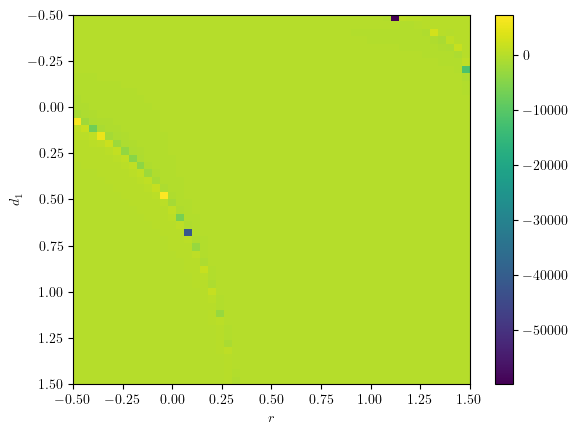

In [5]:
N = 50
h = 0.2
def max_der(R,d):
    items = []
    for i in range(2):
        for j in range(2):
            items.append(np.abs(dip_derivative_full(R,i,j,d,100)))
    return items[0]#max(items)
R = np.stack((np.linspace(0,1,N),np.ones(N)*h))
d1 = np.linspace(0,1,N)
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])

V = np.zeros((N,N))
V_der = np.zeros((N,N))
for i in range(N):#
    for j in range(N):
        V[i,j] = dip_dip(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))
        V_der[i,j] = max_der(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))

fig, ax = plt.subplots(1,1)
im = ax.imshow(V_der/V,extent=(-0.5,1.5,1.5,-0.5),aspect='auto')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$d_1$')
plt.colorbar(im,ax=ax)
plt.show()

# fig, ax = plt.subplots(1,2)
# for i in range(N):#
#     ax[0].scatter(R[0,i],max_der(R[:,i],d)/dip_dip(R[:,i],d),color='0')
#     ax[1].scatter(R[0,i],dip_dip(R[:,i],d),color='0')
# plt.show()


In [5]:
from scipy.optimize import minimize, root_scalar
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))
b0 =1.8
a = 3
freq = 1
h = 0.4
N = 20
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
d= np.array([0,1])
def time_traj(t):
    b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    Delta = np.sin(2*np.pi*freq*t)
    dx = dip_zero_der(b,h)
    d = np.array([dx,np.sqrt(1-dx**2)])
    return b, h, Delta, d
rx = np.linspace(0.5,4,N)
t = np.linspace(0,1,N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
Delta = np.zeros(N)
for i in range(N):
    rx[i], h, Delta[i], d = time_traj(t[i])
    V_der[i] = dip_derivative_full(np.array([rx[i],h]),0,0,d,100)
    V[i] = dip_dip(np.array([rx[i],h]),d)
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),d)
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,d,100)
    


# fig, ax = plt.subplots(2,2,figsize=(6,5))
# # ax[0].scatter(rx,opt_h)
# # ax[0].scatter(rx,opt_d1)
# ax[0,0].scatter(t,V)
# ax[0,1].scatter(t,V_der)
# ax[1,0].scatter(rx,V)
# ax[1,1].scatter(rx,V_der)
# ax[0,0].set_xlabel(r'$t$')
# ax[0,0].set_ylabel(r'$V_\text{dip}$',rotation=0)
# ax[0,1].set_xlabel(r'$t$')
# ax[0,1].set_ylabel(r'$V_\text{cpl.}$',rotation=0,labelpad=10)
# ax[1,0].set_xlabel(r'$b$')
# ax[1,0].set_ylabel(r'$V_\text{dip}$',rotation=0)
# ax[1,1].set_xlabel(r'$b$')
# ax[1,1].set_ylabel(r'$V_\text{cpl.}$',rotation=0,labelpad=10)
# plt.subplots_adjust(wspace=0.4,hspace=0.3)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V,s=10)
ax2[1].scatter(rx,V_der,s=10)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"interaction_ricemele_chain4.pdf")
plt.show()





IndexError: invalid index to scalar variable.

In [ ]:
V_der[0], V[0]

(np.float64(0.11303015793764848), np.float64(0.031389654127400045))

In [ ]:
h = 0.4
a = 2
b = 1.8#a/2
# d = np.array([0,1])
dx = dip_zero_der(b,h)
d = np.array([dx,np.sqrt(1-dx**2)])
dip_derivative_full(np.array([b,h]),0,0,d,100),  dip_dip(np.array([b,h]),d)

(np.float64(0.11303015793764848), np.float64(0.031389654127400045))

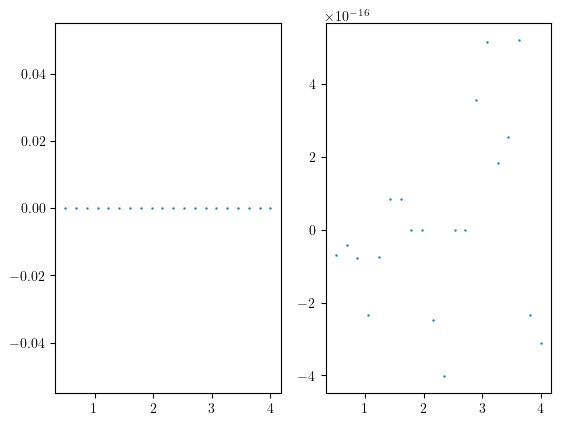

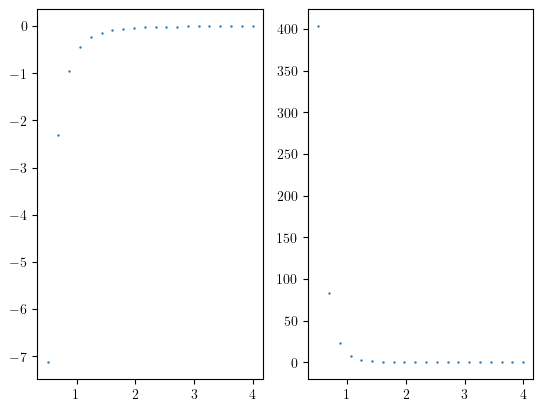

In [7]:
from scipy.optimize import minimize
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))

rx = np.linspace(0.5,4,N)
opt_h = np.ones(N)
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    res = minimize(ratio,x0=[opt_h[i-1],opt_d1[i-1]],args=(rx[i],),bounds=((0.15,1),(0,np.pi)))
    opt_h[i] = 0.2
    opt_d1[i] = np.arcsin(np.sqrt(1/3))
    opt_ratio[i] = res.fun
    V_der[i] = dip_derivative_full(np.array([rx[i],opt_h[i]]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)
    V[i] = dip_dip(np.array([rx[i],opt_h[i]]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)


fig, ax = plt.subplots(1,2)
# ax[0].scatter(rx,opt_h)
# ax[0].scatter(rx,opt_d1)
ax[0].scatter(rx,V2/V)
ax[1].scatter(rx,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V)
ax2[1].scatter(rx,V_der)
plt.show()





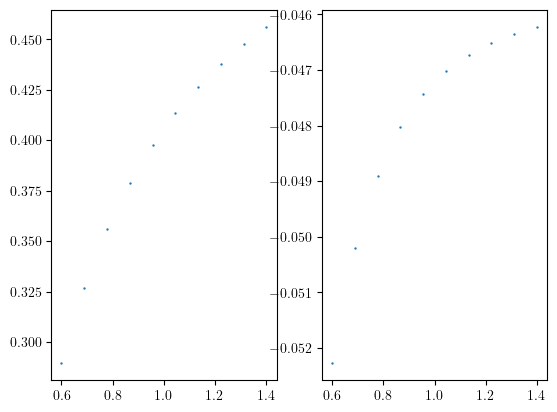

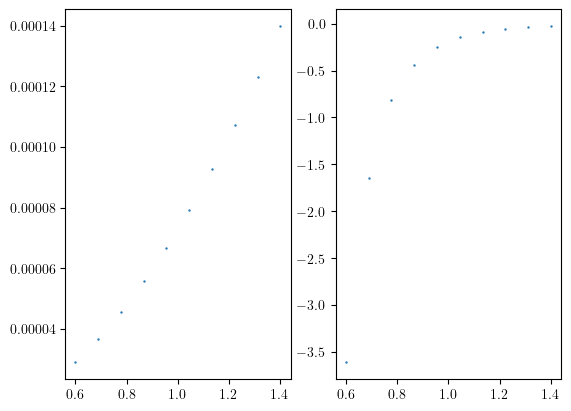

In [ ]:
from scipy.optimize import root_scalar, minimize_scalar
def null(dx,R,sign):
    a = R[0]
    h = R[1]
    return 3*(a**2*dx**2+h**2*(1-dx**2)+sign*2*a*h*dx*np.sqrt(1-dx**2))-(a**2+h**2)
h = 0.35
N = 10
def ratio(h,rx):
    r = root_scalar(null,args=(np.array([rx,h]),1),bracket=(0,1))
    d = np.array([r.root,np.sqrt(1-r.root**2)])
    return np.abs(dip_derivative_full(np.array([rx,h]),0,0,d,100)/dip_derivative_full(np.array([rx*2,0]),0,0,d,100))
x = np.linspace(0.6,1.4,N)
opt_h = np.ones(N)*0.2
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    # res = minimize_scalar(ratio,args=(x[i],),bounds=((0.2,0.35)))
    opt_h[i] = 0.2#res.x
    r = root_scalar(null,args=(np.array([x[i],opt_h[i]]),1),bracket=(0,1))
    # r2 = root_scalar(null,args=(np.array([x[i],h]),-1),bracket=(0,1))
    opt_d1[i] = r.root
    V[i] = dip_dip(np.array([4*3*x[i],0]),np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]))
   
    V_der[i] = dip_derivative_full(np.array([x[i],opt_h[i]]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)
    V_der2[i] = dip_derivative_full(np.array([x[i]*2,0]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)

fig, ax = plt.subplots(1,2)
# ax[0].scatter(x,opt_h)
ax[0].scatter(x,opt_d1)
# ax[0].scatter(x,opt_ratio)
ax[1].scatter(x,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(x,V/V_der)
ax2[1].scatter(x,V_der2)
plt.show()



In [6]:
import scipy.constants as c

a0 = 4*np.pi*c.epsilon_0*c.hbar**2/(c.m_e*c.e**2)
d = np.array([1000,5000])*c.e*a0
r0 = np.array([10,3])/10**6
V = d**2/(4*np.pi*c.epsilon_0*r0**5)#*np.sqrt(c.hbar/2/m/w)**2
V#/c.hbar

array([6.46047512e-18, 6.64657935e-14])

In [7]:
m = 85.5*c.u
w = 2*np.pi*10**3*np.array([10,50])
r= np.array([3,12])/10**6
np.sqrt(c.hbar/m/2/w)/r, np.sqrt(c.hbar/2/m/w)
# m*w**2*r**2/V[::-1]

(array([0.02562738, 0.00286523]), array([7.68821539e-08, 3.43827445e-08]))

In [137]:
c.hbar*w

array([3.31303507e-29, 6.62607015e-30])

In [136]:
m*w**2

array([1.40124785e-14, 5.60499139e-16])

In [11]:
A = np.ones((4,2))
A[:,0] = np.sqrt(1/3)
A[:,1] = np.sqrt(2/3)
array_norm = np.vectorize(np.linalg.norm)
np.linalg.norm(A,axis=1), A

(array([1., 1., 1., 1.]),
 array([[0.57735027, 0.81649658],
        [0.57735027, 0.81649658],
        [0.57735027, 0.81649658],
        [0.57735027, 0.81649658]]))

In [ ]:
latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
b = 0.5
latticeB = np.stack((np.arange(1,chain_length//2+1)*b,np.ones(chain_length//2)*h)).T
i=0
dist = np.concatenate((latticeA[i]-latticeA[:i],latticeA[i+1:]-latticeA[i]))

In [50]:
def grad_long_range(b,h,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    indA = np.arange(latticeA.shape[0],dtype=np.int16)
    indB = np.arange(latticeB.shape[0],dtype=np.int16)
    grad_vec = np.zeros(chain_length)
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),-interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),-interaction(latticeB[i:]-latticeA[i],d)))
        grad_vec[2*i] = np.sum(interAA[i])+np.sum(interAB[i])
    
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),-interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),-interaction(latticeA[i+1:]-latticeB[i],d)))
        grad_vec[2*i+1] = np.sum(interBB[i])+np.sum(interBA[i])
    # print(interAA)
    # print(interAB)
    # print(interBB)
    # print(interBA)
    if cut:
        return np.where(np.abs(grad_vec)<cut,0,grad_vec)
    return grad_vec

def hopping_Ham2(b,h,Delta,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),interaction(latticeB[i:]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[2*i,2::2] = interAA[i]
        dmat[2*i,1::2] = interAB[i]
        dmat[2*i,2*i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),interaction(latticeA[i+1:]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[2*i+1,2::2] = interBB[i]
        dmat[2*i+1,1::2] = interBA[i]
        dmat[2*i+1,2*i+1] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
    return dmat

def hopping_Ham(b,h,Delta,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    # print("lattice",latticeA[0]-latticeA[:0])
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),interaction(latticeB[i:]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[2*i,:2*i:2] = interAA[i][:i]
        dmat[2*i,2*(i+1)::2] = interAA[i][i:]
        dmat[2*i,1::2] = interAB[i]
        dmat[2*i,2*i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),interaction(latticeA[i+1:]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[2*i+1,1:2*i+1:2] = interBB[i][:i]
        dmat[2*i+1,2*(i+1)+1::2] = interBB[i][i:]
        dmat[2*i+1,::2] = interBA[i]
        dmat[2*i+1,2*i+1] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
    if cut:
        return np.where(np.abs(dmat)<cut,0,dmat)
    return dmat



def hopping_Ham_cut(b,h,Delta,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    # print("lattice",latticeA[0]-latticeA[:0])
    def f(x):
        if x<0:
            return 0
        elif x>=chain_length:
            return chain_length
        else:
            return x
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[f(i-cut):i],d),interaction(latticeA[i+1:f(i+cut+1)]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[f(i-cut):i],d),interaction(latticeB[i:f(i+cut)]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[2*i,:2*i:2] = interAA[i][:i]
        dmat[2*i,2*(i+1)::2] = interAA[i][i:]
        dmat[2*i,1::2] = interAB[i]
        dmat[2*i,2*i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[f(i-cut):i],d),interaction(latticeB[i+1:f(i+cut+1)]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[f(i+1-cut):i+1],d),interaction(latticeA[i+1:f(i+1+cut)]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[2*i+1,1:2*i+1:2] = interBB[i][:i]
        dmat[2*i+1,2*(i+1)+1::2] = interBB[i][i:]
        dmat[2*i+1,::2] = interBA[i]
        dmat[2*i+1,2*i+1] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
    return dmat

def hopping_Ham_k(k,b,h,Delta,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((2,2),dtype=np.complex128)
    
    distAA = np.zeros((latticeA.shape[0]-1,2))
    distAB = np.zeros((latticeB.shape[0],2))
    # print("lattice",latticeA[0]-latticeA[:0])
    i = chain_length//4
    distAA = np.concatenate((latticeA[i]-latticeA[:i],latticeA[i+1:]-latticeA[i]))
    interAA = interaction(distAA,d)
    distAB = np.concatenate((latticeA[i]-latticeB[:i],latticeB[i:]-latticeA[i]))
    interAB = interaction(distAB,d)

    distBB = np.zeros((latticeB.shape[0]-1,2))
    distBA = np.zeros((latticeA.shape[0],2))
    
    distBB = np.concatenate((latticeB[i]-latticeB[:i],latticeB[i+1:]-latticeB[i]))
    interBB = interaction(distBB,d)
    distBA = np.concatenate((latticeB[i]-latticeA[:i+1],latticeA[i+1:]-latticeB[i]))
    interBA = interaction(distBA,d)
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
    cell_list = [n for n in range(chain_length//2)]
    
    unit_distAA = (np.array(cell_list[:i] +cell_list[i+1:])-i)*a
    unit_distAB = (np.array(cell_list)-i)*a
    dmat[0,0] = np.sum(interAA*np.exp(-1j*k*unit_distAA))
    dmat[0,1] = np.sum(interAB*np.exp(-1j*k*unit_distAB))
    dmat[0,0] += - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
    dmat[1,0] = np.sum(interBA*np.exp(-1j*k*unit_distAB))
    dmat[1,1] = np.sum(interBB*np.exp(-1j*k*unit_distAA))
    dmat[1,1] += - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta

    return dmat

def BdG_Ham(b,h,Delta,a,chain_length,interaction,d):
    dmat = hopping_Ham(b,h,Delta,a,chain_length,interaction,d)
    dmat_BdG = np.zeros((2*chain_length,2*chain_length))
    dmat_BdG[:chain_length,:chain_length] = dmat
    dmat_BdG[:chain_length,chain_length:] = dmat
    dmat_BdG[chain_length:,chain_length:] = -dmat
    dmat_BdG[chain_length:,:chain_length] = -dmat
    return dmat_BdG

def BdG_Ham_k(k,b,h,Delta,a,chain_length,interaction,d):
    dmat = hopping_Ham_k(k,b,h,Delta,a,chain_length,interaction,d)
    dmat_BdG = np.zeros((4,4),dtype=np.complex128)
    dmat_BdG[:2,:2] = dmat
    dmat_BdG[:2,2:4] = dmat
    dmat_BdG[2:4,:2] = -dmat
    dmat_BdG[2:4,2:4] = -dmat
    
    return dmat_BdG

chain_length = 4
b0 = 0.3
h = 0.2
dmat = hopping_Ham(b0,h,0,a,chain_length,lambda x, y: dip_derivative_full_vec(x,y),d)
dmat_nn = nearest_nb_Hamiltonian(b0,h,a,chain_length,lambda x, y: dip_derivative_full(x,0,0,y),0,d)
# # # gradient_nn = grad(b,h,a,chain_length,nom_der1,d)
# # # gradient = grad_long_range(b,h,a,chain_length,nom_der1_vec,d)
# # # gradient, gradient_nn
dmat, dmat_nn

(array([[ 460.01805991, -489.42421291,   24.        ,    5.40615299],
        [-489.42421291,  389.42614917,   75.99806374,   24.        ],
        [  24.        ,   75.99806374,  389.42614917, -489.42421291],
        [   5.40615299,   24.        , -489.42421291,  460.01805991]]),
 array([[ 489.42421291, -489.42421291,    0.        ,    0.        ],
        [-489.42421291,  413.42614917,   75.99806374,    0.        ],
        [   0.        ,   75.99806374,  413.42614917, -489.42421291],
        [   0.        ,    0.        , -489.42421291,  489.42421291]]))

In [78]:
chain_length = 1000
k = 0*np.pi/(a*chain_length)
b0=0.5
dmat = hopping_Ham_k(k,b0,h,0,a,chain_length,lambda x, y: dip_derivative_full_vec(x,y),d)
# np.max(np.abs(dmat - np.conjugate(dmat.T)))
np.real(dmat)

array([[-182.79574069,  423.26662863],
       [ 423.26662863, -182.79574069]])

In [27]:
dmat = BdG_Ham(b0,h,0,a,chain_length,lambda x, y: dip_derivative_full_vec(x,y),d)
np.sum(np.linalg.eigvals(dmat)), np.max(np.abs(np.imag(np.linalg.eigvals(dmat)))), np.min(np.abs(np.imag(np.linalg.eigvals(dmat)))), np.max(np.abs(np.real(np.linalg.eigvals(dmat)))), np.min(np.abs(np.real(np.linalg.eigvals(dmat)))), np.max(np.abs(np.linalg.eigvals(dmat))), np.min(np.abs(np.linalg.eigvals(dmat)))

(np.complex128(4.012908932151402e-13+0j),
 np.float64(6.4302748424451125e-06),
 np.float64(0.0),
 np.float64(4.914275973896654e-06),
 np.float64(6.899015438768533e-14),
 np.float64(6.430274842445114e-06),
 np.float64(6.899015438768533e-14))

In [10]:
def grad_long_range_spph2(b,h,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    indA = np.arange(latticeA.shape[0],dtype=np.int16)
    indB = np.arange(latticeB.shape[0],dtype=np.int16)
    grad_vec = np.zeros((chain_length**2-chain_length)//2)
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    for i in range(latticeA.shape[0]):
        interAA[i,:i] = interaction(latticeA[i]-latticeA[:i],d)
        interAB[i,:i] = interaction(latticeA[i]-latticeB[:i],d)
        grad_vec[(2*i-1)*i:(2*i+1)*i:2] = interAA[i,:i]
        grad_vec[(2*i-1)*i+1:(2*i+1)*i:2] = interAB[i,:i]
        # grad_vec[2*i] = np.sum(interAA[i])+np.sum(interAB[i])
    
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i,:i] = interaction(latticeB[i]-latticeB[:i],d)
        interBA[i,:i+1] = interaction(latticeB[i]-latticeA[:i+1],d)
        grad_vec[(2*i+1)*i+1:(2*i+1)*(2*i+2)//2:2] = interBB[i,:i]
        grad_vec[(2*i+1)*i:(2*i+1)*(2*i+2)//2:2] = interBA[i,:i+1]
    # print(interAA)
    # print(interAB)
    # print(interBB)
    # print(interBA)
    return grad_vec

def grad_long_range_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    lattice = np.zeros((chain_length,2))
    lattice[::2] = latticeA
    lattice[1::2] = latticeB
    
    grad_vec = np.zeros((chain_length**2-chain_length)//2)
    
    for i in range(chain_length):
        for j in range(i):
            inter = interaction(lattice[i]-lattice[j],d)
            grad_vec[(i-1)*i//2+j] =  inter
    return grad_vec

def hopping_Ham_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    lattice = np.zeros((chain_length,2))
    lattice[::2] = latticeA
    lattice[1::2] = latticeB
    dmat = np.zeros(((chain_length**2-chain_length)//2,chain_length))
    # print("lattice",latticeA[0]-latticeA[:0])
    for i in range(lattice.shape[0]):
        for j in range(i):
            inter = interaction(lattice[i]-lattice[j],d)
            dmat[(i-1)*i//2+j,i] =  inter
            dmat[(i-1)*i//2+j,j] = -inter
        
    return dmat

chain_length = 4
b = 0.3
h = 0.2
g = grad_long_range_spph(b,h,a,chain_length,nom_der1,d)
g2 = grad_long_range_spph2(b,h,a,chain_length,nom_der1_vec,d)
dmat = hopping_Ham_spph(b,h,a,chain_length,lambda x, y: dip_derivative_full(x,0,0,y),d)

dis = np.linalg.lstsq(dmat,g)[0]
print(np.linalg.norm(g-dmat@dis),dis)
g2-g
def matrix_eq(dis,A,B):
    return np.sum((A@dis-B)**2)+np.linalg.norm(dis)#,method="Nelder-Mead"

minimize(matrix_eq,x0=np.ones(chain_length),args=(dmat,g))
    

5.640852667260002 [ 0.01438177 -0.12452199  0.12452199 -0.01438177]


  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 31.996480802848634
        x: [ 1.377e-02 -1.251e-01  1.239e-01 -1.504e-02]
      nit: 7
      jac: [ 2.656e-04 -2.751e-04 -1.249e-04  2.489e-04]
 hess_inv: [[ 5.001e-02  5.000e-02  4.997e-02  4.997e-02]
            [ 5.000e-02  5.000e-02  4.996e-02  4.997e-02]
            [ 4.997e-02  4.996e-02  5.000e-02  5.001e-02]
            [ 4.997e-02  4.997e-02  5.001e-02  5.002e-02]]
     nfev: 272
     njev: 52

In [106]:
def ratio_first_order(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
   
    dmat = hopping_Ham_spph(b,h,a,chain_length,lambda x, y: dip_derivative_full(x,0,0, y),d)
    beta = grad_long_range_spph(b,h,a,chain_length,nom_der1,d)
    dis = np.linalg.lstsq(dmat,beta)[0]
    return np.max(np.abs(beta))/np.min(np.where(dmat==0,np.inf,np.abs(dmat)))+np.linalg.norm(dis)*10#/np.min(np.where(dmat==0,np.inf,np.abs(dmat)),axis=1)))
def lst_wrapper(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
   
    dmat = hopping_Ham_spph(b,h,a,chain_length,lambda x, y: dip_derivative_full(x,0,0, y),d)
    beta = grad_long_range_spph(b,h,a,chain_length,nom_der1,d)
    dis = np.linalg.lstsq(dmat,beta)[0]
    return np.linalg.norm(dis)

grid_phi = np.linspace(-np.pi,np.pi,50)
h_grid = np.linspace(0.1,0.5,50)
min_vals = []
min_phi = []
min_h = []
norm_dis = []
for n in range(len(grid_phi)):
    for m in range(len(h_grid)):
        # res = minimize(ratio_first_order,x0=[grid_phi[n],h_grid[m]],args=b,bounds=((-np.pi,np.pi),(-0.5,0.5)))
        res = minimize(lst_wrapper,x0=[grid_phi[n],h_grid[m]],args=b,bounds=((-np.pi,np.pi),(0.1,0.5)))
        d = np.array([np.cos(res.x[0]),np.sin(res.x[0])])
        beta = grad_long_range_spph(b,res.x[1],a,chain_length,nom_der1,d)
        dmat = hopping_Ham_spph(b,res.x[1],a,chain_length,lambda x, y: dip_derivative_full(x,0,0, y),d)
        # res2 = minimize(matrix_eq,x0=np.ones(chain_length),args=(dmat,beta)) 
        # dis = res2.x
        dis = np.linalg.lstsq(dmat,beta)[0]
        min_vals.append(np.max(np.abs(beta-dmat@dis))/np.min(np.where(dmat==0,np.inf,np.abs(dmat))))
        # min_vals.append(res2.fun)
        min_phi.append(res.x[0])
        min_h.append(res.x[1])
        norm_dis.append(np.linalg.norm(dis))

        
crit = np.array([min_vals, min_phi, min_h,norm_dis]).T
sorted_crit = sorted(crit, key=lambda x: x[0]+x[-1])
    

fuss = sorted_crit[0][1]
haes = sorted_crit[0][2]
sorted_crit[0]#[0], sorted_crit[0][3]
        # print("final minimum: ",res2.fun)    #
        # print(res.fun/np.min(np.where(dmat==0,np.inf,np.abs(dmat))))

array([0.19840326, 0.74703958, 0.11917948, 0.18976396])

In [104]:
sorted_crit[0]

array([ 1.05527818e-13,  3.14159265e+00, -5.45307617e-09,  2.61007663e-01])

-552.9599999999999 8.72803724096948
-165.72815184059726 10.737125675840087
10.876714746815958 13.319836701474236
68.16980108366482 16.662961941154958
75.87741615288857 21.012684423682003
67.08203932499364 26.681717757670675
54.78826254364981 34.034052732255496
43.3992138918854 43.3992138918854
34.034052732255525 54.78826254364976
26.681717757670697 67.08203932499362
21.012684423681968 75.87741615288849
16.662961941154958 68.16980108366498
13.319836701474236 10.876714746815958
10.737125675840105 -165.7281518405965
8.72803724096948 -552.9599999999998


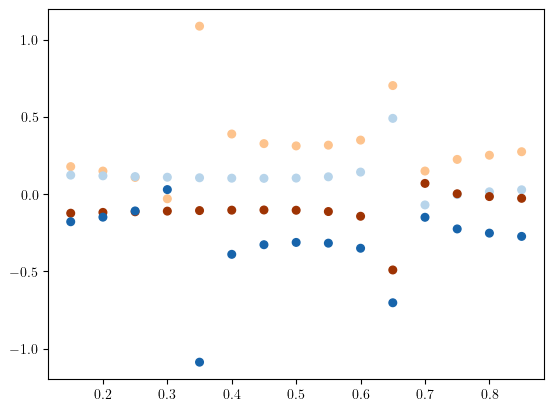

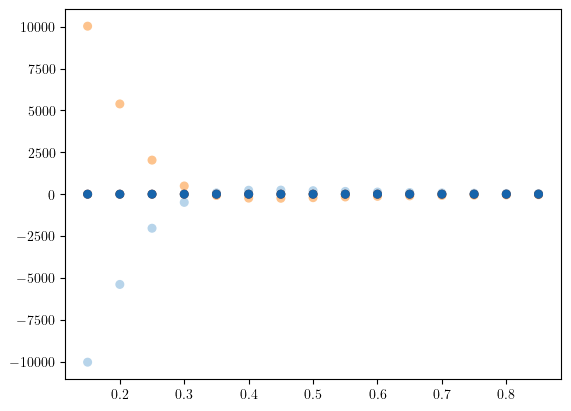

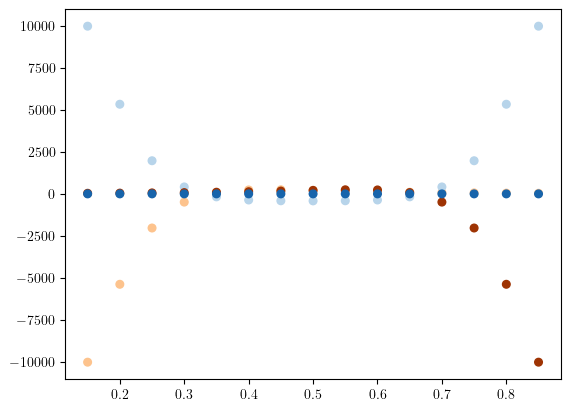

In [8]:
def grad(b,h,a,chain_length,interaction,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction(dist1,d)
    grad2 = interaction(dist2,d)
    grad_vec = np.zeros(chain_length)
    print(grad1,grad2)
    grad_vec[0] = -grad1
    grad_vec[1:-1] = -grad2+grad1
    grad_vec[-1] = grad1-(grad1-grad2)*(chain_length%2)
    grad_vec[1:-1] *= (-1)**np.arange(chain_length-2)
    return grad_vec
    return grad1, grad2
    return dist1, dist2



def nearest_nb_Hamiltonian(b,h,a,chain_length,interaction,Delta,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = interaction(latticeB[:,0]-latticeA[:,1],d)
    dmat[ind[:-1:2],ind[1::2]]= inter_1
    dmat[ind[1::2],ind[:-1:2]]= inter_1
    dmat[ind[1:-1:2],ind[2::2]] = inter_2
    dmat[ind[2::2],ind[1:-1:2]] = inter_2
    dmat[0,0] = -inter_1
    dmat[-1,-1] = -inter_1-(inter_2-inter_1)*(chain_length%2)
    dmat[ind[1:-1],ind[1:-1]] = -inter_1-inter_2 
    # dmat[ind[2:-1:2],ind[2:-1:2]]= -Delta
    # print(inter_1,inter_2,b)
    return dmat#


import matplotlib.cm as cm
orange = cm.Oranges
blue = cm.Blues
chain_length = 4
N = 15
# b = np.linspace(0.465,0.535,N)
b = np.linspace(0.15,0.85,N)
h = 0.2
a = 1
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
d = np.array([1,0])
eigenvecs = np.zeros((N,chain_length))
dist1 = np.zeros(N)
dist2 = np.zeros(N)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
colors = np.zeros((chain_length,4))
colors[::2] = orange(np.linspace(0.3,0.9,chain_length//2+chain_length%2))
colors[1::2] = blue(np.linspace(0.3,0.8,chain_length//2))
for i in range(N):
    dmat = nearest_nb_Hamiltonian(b[i],h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]
    beta = grad(b[i],h,a,chain_length,nom_der1,d)
    # eig, vecs = np.linalg.eig(dmat)
    # eigenvecs[i,:] = sorted(eig)
    eigenvecs[i,:] = np.linalg.solve(dmat,beta)
    # ax.scatter(b[i]*np.ones(chain_length-2),beta[::3],color='0')
    # ax.scatter(b[i]*np.ones(chain_length-2),eigenvecs[i,2:],color=colors[:2],s=30)
    ax.scatter(b[i]*np.ones(chain_length),eigenvecs[i,:],color=colors,s=30)
    # dist1[i], dist2[i] = grad(b[i],h,a,chain_length,nom_der1,d)
    # ax.scatter(b[i]*np.ones(chain_length),beta,color='0')
    ax2.scatter(b[i]*np.ones(chain_length),dmat[:,0],color=colors,s=30)
    ax3.scatter(b[i]*np.ones(chain_length),dmat[:,1],color=colors,s=30)
    # ax.scatter(b[i]*np.ones(1),dist1,color='0')
    # ax.scatter(b[i]*np.ones(1),dist2,color='red')
# ax.scatter(b,dist1,color='0')
# ax.scatter(b,dist2[::-1],color='red')
# ax.set_ylim(-3,3)
plt.show()


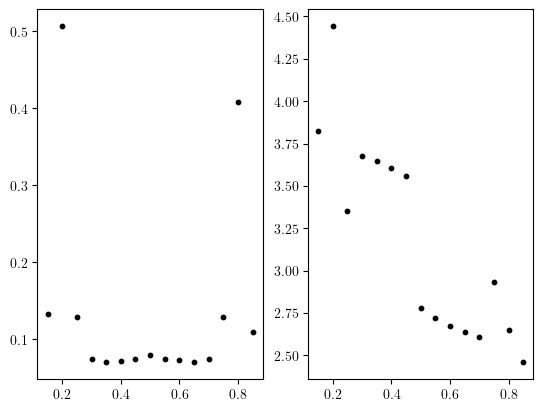

In [ ]:
chain_length = 8
def abs_eigvec(phid,b):
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]
    beta = grad(b,h,a,chain_length,nom_der1,d)
    eigenvecs = np.linalg.solve(dmat,beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize_scalar
b = np.linspace(0.15,0.85,N)
fig, ax = plt.subplots(1,2)
for i in range(N):
    res = minimize_scalar(abs_eigvec,args=b[i],bounds=(0,2*np.pi),method='bounded')
    ax[0].scatter(b[i],res.fun,color='0',s=10)
    ax[1].scatter(b[i],res.x,color='0',s=10)
plt.show()
    

In [140]:
m*w**2/V

array([1.83471841e+18, 1.42667704e+12])

IndexError: list index out of range

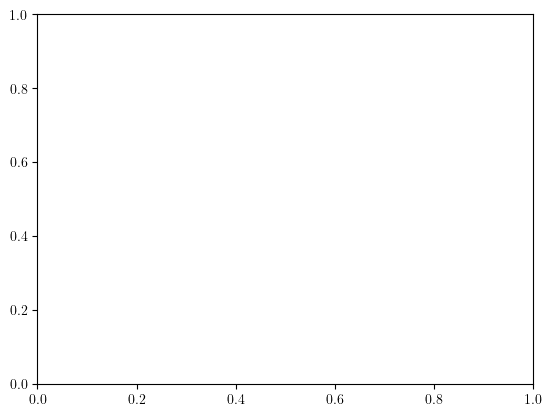

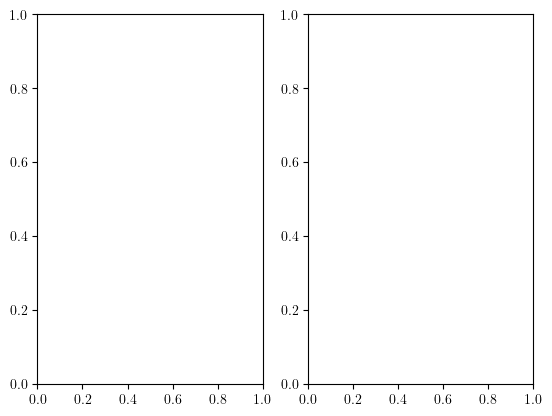

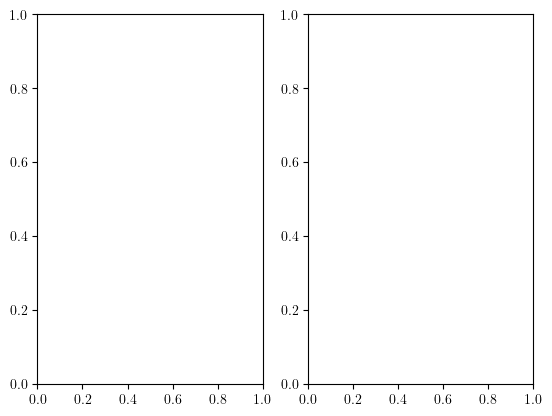

In [13]:
def interaction(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2

def interaction_nnn(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[3*a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2

def min_unwanted(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad(b,h,a,chain_length,nom_der1,d)
    eigenvecs = np.linalg.solve(dmat,beta)
    # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 60
b = np.linspace(0.25,0.75,N)
phis = np.ones(N)*(3.7)
hs = np.ones(N)*0.25
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 16
Deltap = 0.2
Deltah = 0.1
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,10)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,10)+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((0,2*np.pi),(-0.5,0.5)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            except:
                pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = nearest_nb_Hamiltonian(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig, vec = np.linalg.eig(dmat)
    ax3[0].scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    vecp = np.linalg.solve(dmatp,beta)
    dis = dmat@vecp
    ax3[1].scatter(b[i],np.max(dis),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

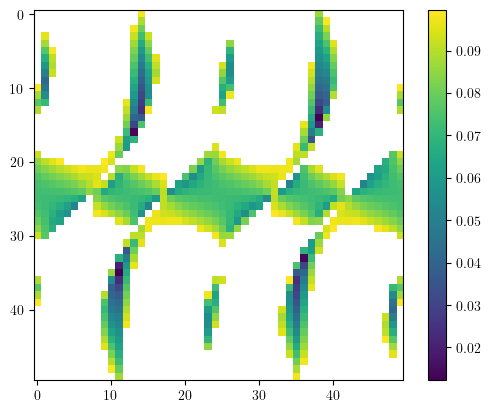

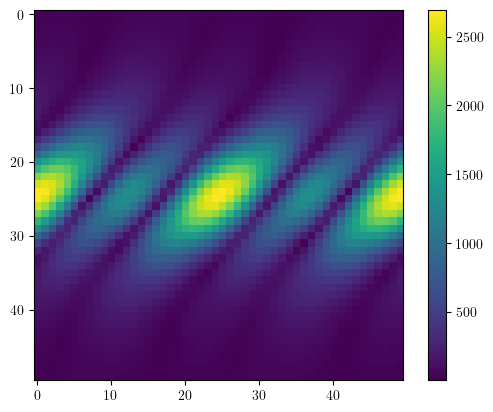

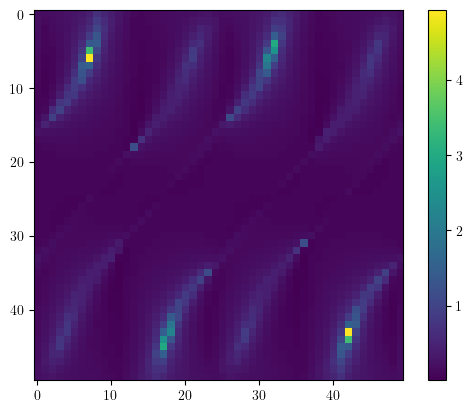

In [120]:
N = 50
phid = np.linspace(-np.pi,np.pi,N)
h = np.linspace(-0.7,0.7,N)
d = np.array([np.cos(phid),np.sin(phid)]).T
cut = 0.05
dis = np.zeros((N,N))
min_dmat = np.zeros((N,N))
min_beta = np.zeros((N,N))
b0 = 0.6
for i in range(N):
    for j in range(N):
        dmat = hopping_Ham(b0,h[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d[j],cut)
        beta = grad_long_range(b0,h[i],a,chain_length,nom_der1_vec,d[j],cut)
        eigenvecs = np.linalg.solve(dmat,beta)
        dis[i,j] = np.max(np.abs(beta))/np.max(np.where(np.abs(dmat)==0,0,np.abs(dmat)))
        min_dmat[i,j] = np.max(np.abs(dmat))#np.min(np.where(np.abs(dmat)==0,np.inf,np.abs(dmat)))
        min_beta[i,j] = np.max(np.abs(beta))
        dis[i,j] = dis[i,j] if dis[i,j]<0.1 else np.nan
        
fig, ax = plt.subplots(1,1)
im = ax.imshow(dis)
cmap = fig.colorbar(im,ax=ax)
fig2, ax2 = plt.subplots(1,1)
im2 = ax2.imshow(min_dmat)
cmap2 = fig2.colorbar(im2,ax=ax2)
fig3, ax3 = plt.subplots(1,1)
im3 = ax3.imshow(min_beta/min_dmat)
cmap3 = fig3.colorbar(im3,ax=ax3)
plt.show()

5.944035443348059 7.399454371356316
0.22869832746417654 14.429457547598696
7.422322928999722 7.260145291090606
6.822248828113363 7.586292044223034
6.488968549418391 6.672905639806388


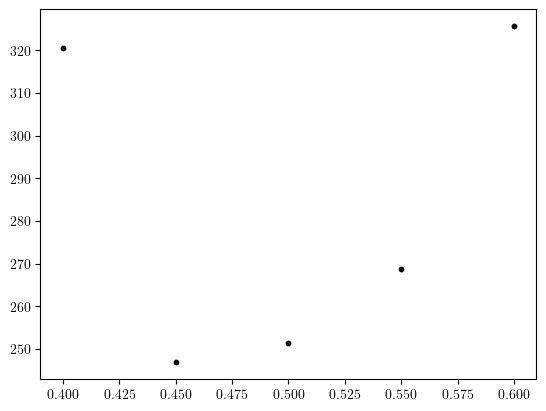

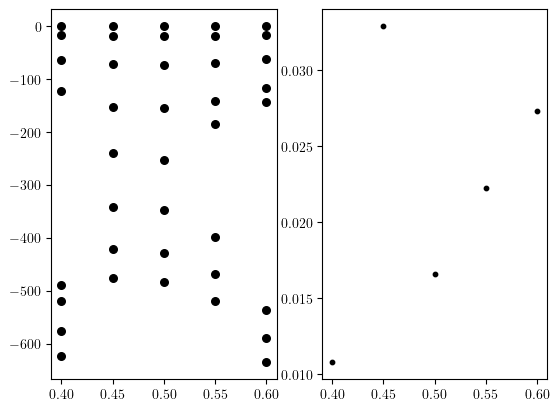

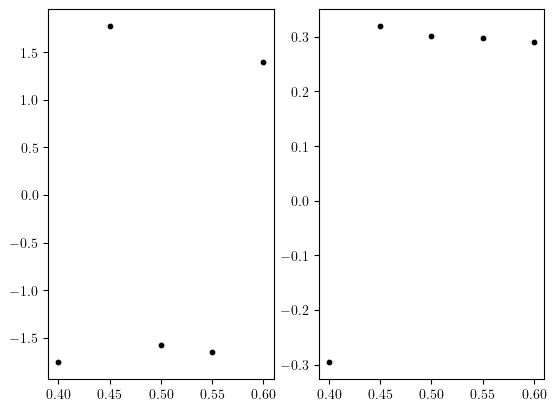

In [94]:
a = 1
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    # dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    cut = 0.05
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # beta = grad(b,h,a,chain_length,nom_der1,d)
    dmat = hopping_Ham(b,h,1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
    # dmat = hopping_Ham(b,h,(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d)
    beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
    # return np.max(np.abs(beta))/np.min(np.where(dmat==0,np.inf,np.abs(dmat)))
    eigenvecs = np.linalg.solve(dmat,beta)
    # # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 5
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.4,0.6,N)
phis = np.ones(N)*(np.pi/2)
hs = np.ones(N)*-0.25
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 8
Deltap = np.pi#0.2
Deltah = 0.7
grid_numb = 10
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,grid_numb)#+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,grid_numb)#+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((-2*np.pi,2*np.pi),(-0.7,0.7)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            except:
                pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = nearest_nb_Hamiltonian(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig, vec = np.linalg.eig(dmat)
    ax3[0].scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # vecp = np.linalg.solve(dmatp,beta)
    # dis = dmat@vecp
    ax3[1].scatter(b[i],sorted_crit[0][0],color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

13.275806024382677 8.934735820096527
203.68142223529148 50.98095698822362
177.85185185185085 56.273437499999886
155.989955832081 62.27087701825966
137.3863220214839 69.0890186539388
121.47520787640956 76.8663951496161
107.80222937943714 85.76960448102406
95.99999999999977 95.99999999999977
85.76960448102406 107.8022293794371
76.8663951496161 121.47520787640956
69.08901865393885 137.38632202148383
62.27087701825966 155.989955832081
56.273437499999886 177.85185185185085
50.98095698822362 203.68142223529162
46.2962962962962 234.37499999999866


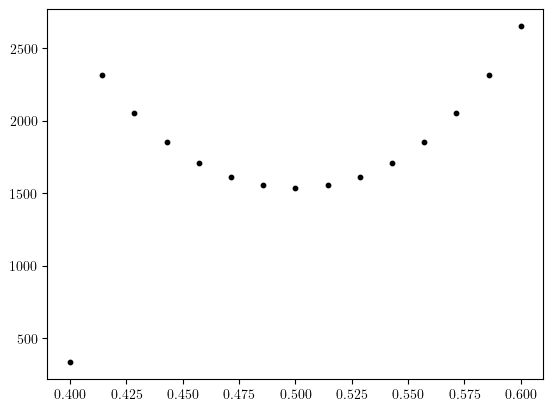

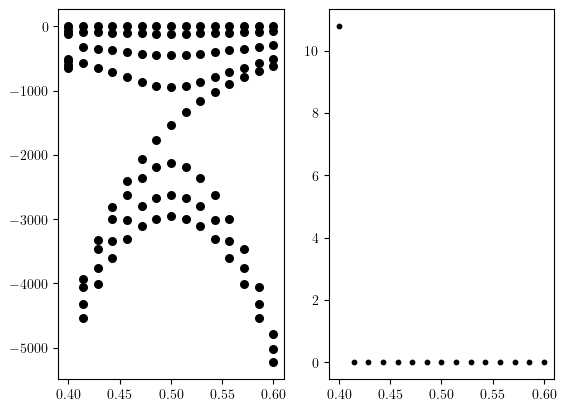

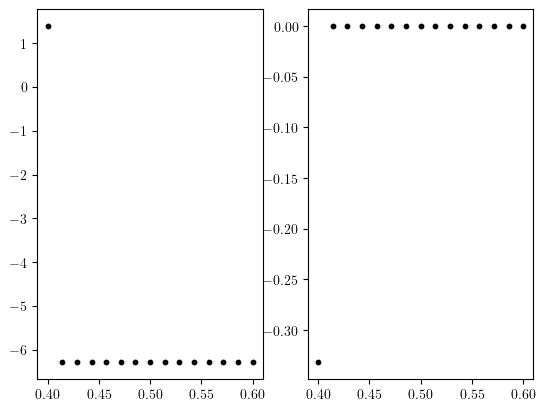

In [ ]:
a = 1
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    # dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    cut = 0.05
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # beta = grad(b,h,a,chain_length,nom_der1,d)
    dmat = hopping_Ham(b,h,0.01,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
    # dmat = hopping_Ham(b,h,(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d)
    beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
    beta_h = grad_long_range(b,h,a,chain_length,gradh,d,cut)
    beta_phi = grad_long_range(b,h,a,chain_length,gradphi,d,cut)
    dmat_h = hopping_Ham(b,h,0.0,a,chain_length,hessh,d,cut)
    dmat_phi = hopping_Ham(b,h,0.0,a,chain_length,hessphi,d,cut)
    dmat_inv = np.linalg.inv(dmat)
    
    v = -dmat_h@ dmat_inv @ beta + beta_h - dmat_phi @ dmat_inv @ beta + beta_phi
    return np.linalg.norm(v)
    # return np.max(np.abs(beta))/np.min(np.where(dmat==0,np.inf,np.abs(dmat)))
    # eigenvecs = np.linalg.solve(dmat+dmat_h+dmat_phi,beta+beta_h+beta_phi)
    # # # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # # return np.linalg.norm(beta)
    # return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 15
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.4,0.6,N)
phis = np.ones(N)*(np.pi/2)
hs = np.ones(N)*-0.25
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 8
Deltap = 0.2
Deltah = 0.1
grid_numb = 3
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,grid_numb)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,grid_numb)+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            # try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((-2*np.pi,2*np.pi),(-0.7,0.7)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            # except:
            #     pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = nearest_nb_Hamiltonian(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig, vec = np.linalg.eig(dmat)
    ax3[0].scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # dmatp = dmat#+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # vecp = np.linalg.solve(dmatp,beta)
    # dis = dmat@vecp
    ax3[1].scatter(b[i],sorted_crit[0][0],color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

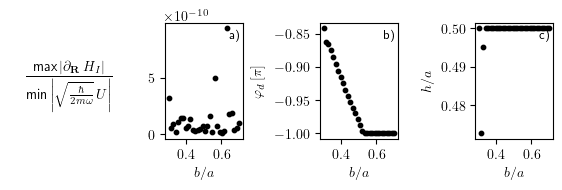

In [ ]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=1.5,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(1,4, figure=fig)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])
# ax4 = fig.add_subplot(gs[1,:2])
# ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
# N = 30
pad = 7
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.3,0.7,N)
for i in range(N):
    
    # dmat = hopping_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmat = hopping_Ham(b[i],hs[i],0,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig = np.linalg.eigvals(dmat)
    # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
    
    
    beta = grad_long_range(b[i],hs[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dis = np.linalg.solve(dmat,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(b[i],np.max(h_new)/(np.min(np.where(dmat==0,np.inf,np.abs(dmat)))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    # ax5.scatter(b[i],np.max(dis),color='0',s=10)
    # ax5.scatter(b[i],np.max(beta),color='0',s=10)
    # ax4.scatter(b[i],np.max(beta)/np.max(np.abs(dmatp)),color='0',s=10)
    # ax4.scatter(b[i],np.max(beta)/np.min(np.where(dmatp==0,np.inf,np.abs(dmatp))),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
# ax4.set_xlabel(r"$b/a$")
# # ax1.text(0.7,0.7,"a)",fontsize=9)

# ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
# ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|G\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right|}$$")
ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|\partial_\mathbf{R}\,H_I\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,U\right|}$$")
# ax5.set_xlabel(r"$b/a$")
# ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
# ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
# ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=1,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"minimizing_first_order.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

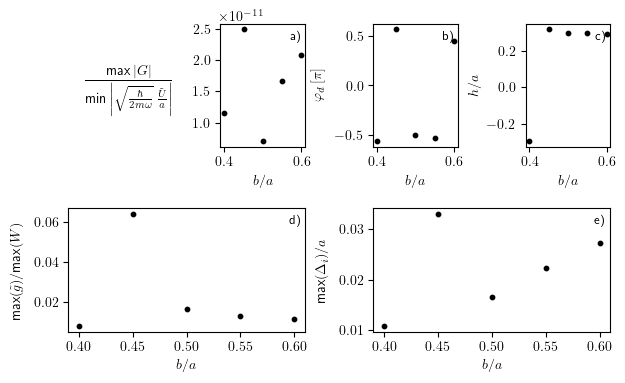

In [ ]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
# N = 30
pad = 7
# b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
for i in range(N):
    
    # dmat = hopping_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmat = hopping_Ham(b[i],hs[i],0.01,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig = np.linalg.eigvals(dmat)
    # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
    
    
    beta = grad_long_range(b[i],hs[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dis = np.linalg.solve(dmat,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(b[i],np.max(h_new)/(np.min(np.where(dmat==0,np.inf,np.abs(dmat)))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    ax5.scatter(b[i],np.max(dis),color='0',s=10)
    # ax5.scatter(b[i],np.max(beta),color='0',s=10)
    ax4.scatter(b[i],np.max(beta)/np.max(np.abs(dmat)),color='0',s=10)
    # ax4.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax4.scatter(b[i],np.max(beta)/np.min(np.where(dmat==0,np.inf,np.abs(dmat))),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|G\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right|}$$")
ax5.set_xlabel(r"$b/a$")
ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero2.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

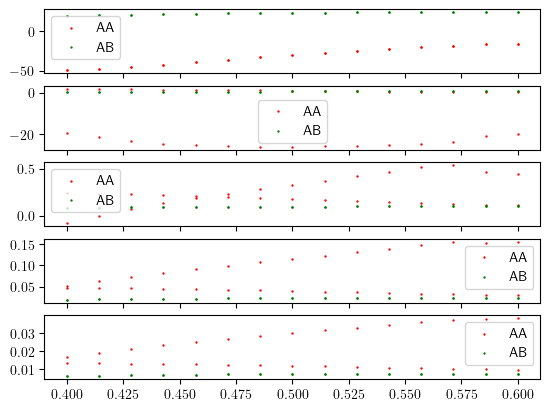

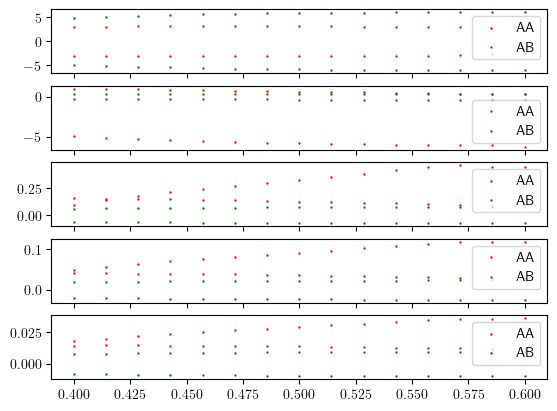

In [47]:
int_range = 5
def interactions(b,h,d,interaction):
    
    interAA = np.zeros((int_range,2))
    interAB = np.zeros_like(interAA)
    for i in range(int_range):
        distAA = np.array([[a*i+b,h],[i*a-b,-h]])
        distAB = np.array([[-a*(i+1),0],[a*(i+1),0]])
        interAA[i] = interaction(distAA,d)
        interAB[i] = interaction(distAB,d)
    return interAA, interAB
fig, ax = plt.subplots(int_range,1,sharex=True)
fig2, ax2 = plt.subplots(int_range,1,sharex=True)
for i in range(N):
    d= np.array([np.cos(phis[i]),np.sin(phis[i])])
    gradAA, gradAB = interactions(b[i],hs[i],d,lambda x, y: dip_derivative_full_vec(x, y))
    hessAA, hessAB = interactions(b[i],hs[i],d,nom_der1_vec)
    for n in range(int_range):
        ax[n].scatter([b[i]]*2,gradAA[n],color='red',label="AA")
        ax[n].scatter([b[i]]*2,gradAB[n],color='green',label="AB")
        ax2[n].scatter([b[i]]*2,hessAA[n],color='red',label="AA")
        ax2[n].scatter([b[i]]*2,hessAB[n],color='green',label="AB")
        if i ==0:
            ax[n].legend()
            ax2[n].legend()

plt.show()


In [118]:
# fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
pad = 7
chain_length = 8
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.3,0.7,N)
eigenvals = np.zeros((N,chain_length//2,4),dtype=np.complex128)
for i in range(N):
    for n in range(chain_length//2):
        k = 2*np.pi*n/((chain_length//2)*a)
        dmat = BdG_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,500,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        eig = np.linalg.eigvals(dmat)
        eigenvals[i,n] = eig
        # ax.scatter(b[i]*np.ones(len(eig)),np.real(eig),color='0',s=10)
        # ax2.scatter(b[i]*np.ones(len(eig)),np.imag(eig),color='0',s=10)
# ax.set_xlabel(r"$b/a$")
# ax.set_ylabel(r"$\text{Re}(\lambda)$")
# plt.show()

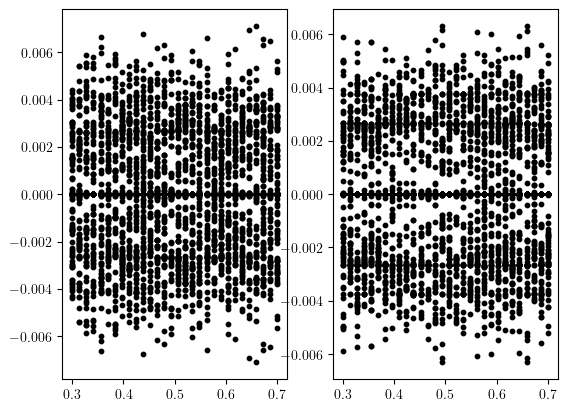

In [23]:
fig, ax = plt.subplots(1,2)
# fig2, ax2 = plt.subplots(1,1)
pad = 7
chain_length = 80
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.3,0.7,N)
# eigenvals = np.zeros((N,chain_length//2,4),dtype=np.complex128)
for i in range(N):
    for n in range(chain_length//2):
        # k = 2*np.pi*n/((chain_length//2)*a)
        # dmat = BdG_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        # # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
      
        eig = eigenvals[i,n]
        ax[0].scatter(b[i]*np.ones(len(eig)),np.real(eig),color='0',s=10)
        ax[1].scatter(b[i]*np.ones(len(eig)),np.imag(eig),color='0',s=10)
# ax.set_xlabel(r"$b/a$")
# ax.set_ylabel(r"$\text{Re}(\lambda)$")
plt.show()

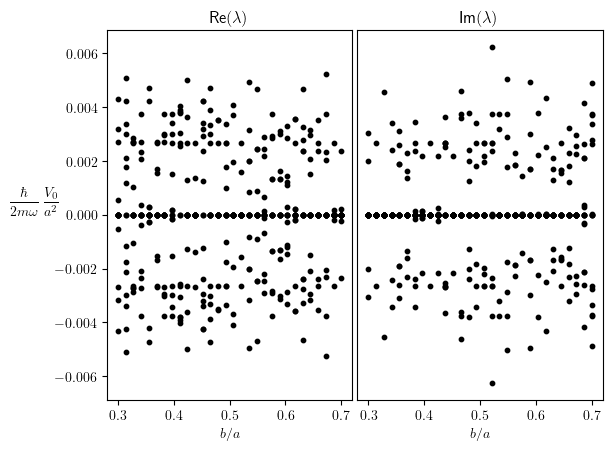

In [119]:
fig, ax = plt.subplots(1,2,sharey=True)
# fig2, ax2 = plt.subplots(1,1)
pad = 15

# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.3,0.7,N)
# eigenvals = np.load("topological_phenomena_dipoles/BdG_spec.npy")
eigenvals2 = np.reshape(eigenvals,shape=(eigenvals.shape[0],eigenvals.shape[1]*eigenvals.shape[2]))
for i in range(N):
    
        
        ax[0].scatter(b[i]*np.ones(eigenvals2.shape[1]),np.real(eigenvals2[i]),color='0',s=10)
        ax[1].scatter(b[i]*np.ones(eigenvals2.shape[1]),np.imag(eigenvals2[i]),color='0',s=10)
ax[0].set_xlabel(r"$b/a$")
ax[0].set_title(r"$\text{Re}(\lambda)$")
ax[0].set_ylabel(r"$$\frac{\hbar}{2m\omega}\,\frac{V_0}{a^2}$$",rotation=0,labelpad = pad)
ax[1].tick_params(axis='y',direction='in',which='both',left=False,right=False,labelleft=False)   

ax[1].set_xlabel(r"$b/a$")
ax[1].set_title(r"$\text{Im}(\lambda)$")
plt.subplots_adjust(wspace=0.02)
plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"Bdg_spec_8N.pdf",bbox_inches='tight')
plt.show()

In [95]:
np.save("topological_phenomena_dipoles/BdG_spec",eigenvals)

In [ ]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    # sorted_comb = sorted(comb, key=lambda x: x[0])
    sorted_comb = sorted(comb, key=lambda x: x[0])
    return np.array(sorted_comb)

In [ ]:
i = 3   
bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))  
eig, vec = np.linalg.eig(bdg)
eigenvals = sort_eigenvalues(eig,vec)
chain_length
j = 6
eigenvals[j,0], eigenvals[2*chain_length-j-1], eigenvals


In [14]:
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad(b,h,a,chain_length,nom_der1,d)
    # eigenvecs = np.linalg.solve(dmat,beta)
    eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 60
b = np.linspace(0.25,0.75,N)
phis_new = np.ones(N)*(3.7)
hs_new = np.ones(N)*0.25
chain_length = 16
Deltap = 0.2
Deltah = 0.1
for i in range(N):
    
    res = minimize(abs_eigvec,x0=(phis[i],hs[i]),args=b[i],bounds=((phis[i]-Deltap,phis[i]+Deltap),(hs[i]-Deltah,hs[i]+Deltah)),tol=1e-12)
   
    

    phis_new[i] = res.x[0]
    hs_new[i] = res.x[1]

In [16]:
pad = 7

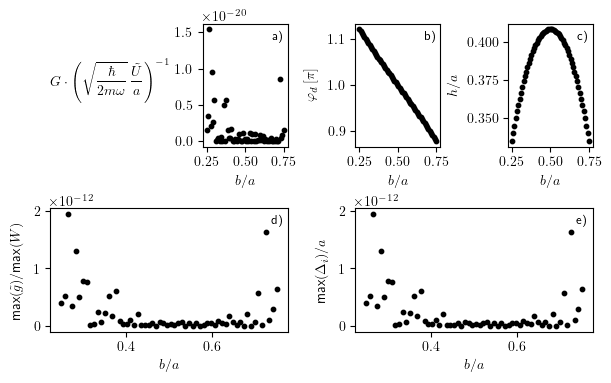

In [17]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))

    eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # dis = np.linalg.lstsq(dmat,beta)[0]
    dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmatp@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    ax5.scatter(b[i],np.max(dis),color='0',s=10)
    ax4.scatter(b[i],np.max(beta)/np.max(np.abs(dmatp)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax0.text(-0.,0.5,r"$$G\cdot\left(\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right)^{-1}$$")
ax5.set_xlabel(r"$b/a$")
ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

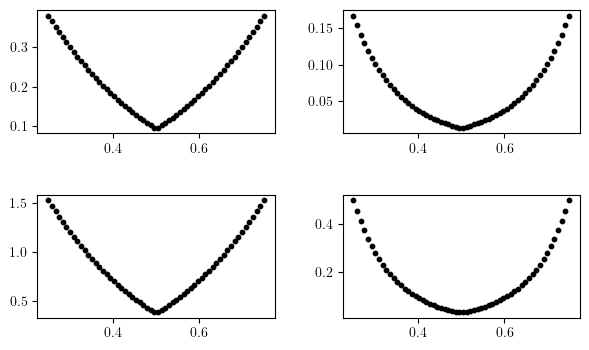

In [23]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
# ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,:2])
ax2 = fig.add_subplot(gs[0,2:])
# ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
def interaction_nnn(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[3*a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    inter1 = interaction_nnn(a,0,a,nom_der1,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    inter2 = interaction_nnn(a+b[i],hs_plot[i],a,nom_der1,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))


    # eig, vec = np.linalg.eig(dmat)
    # # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    # beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # # dis = np.linalg.lstsq(dmat,beta)[0]
    # dis = np.linalg.solve(dmatp,beta)
    # h_new = beta-dmatp@dis
    # # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    # ax1.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    max_dmat = np.min(np.where(np.abs(dmat)==0,np.inf,np.abs(dmat)))
    ax4.scatter(b[i],np.max(np.abs(inter1[2:]))/max_dmat,color='0',s=10)
    ax5.scatter(b[i],np.max(np.abs(inter2[2:]))/max_dmat,color='0',s=10)
    ax1.scatter(b[i],np.max(np.abs(inter1[:2]))/max_dmat,color='0',s=10)
    ax2.scatter(b[i],np.max(np.abs(inter2[:2]))/max_dmat,color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
# ax0.axis("off")
# ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
# ax3.scatter(b,hs_plot,color='0',s=10)
# ax1.set_xlabel(r"$b/a$")
# ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
# ax2.set_xlabel(r"$b/a$")
# ax3.set_ylabel(r"$h/a$")
# ax3.set_xlabel(r"$b/a$")
# ax4.set_xlabel(r"$b/a$")
# # ax1.text(0.7,0.7,"a)",fontsize=9)

# ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
# ax0.text(-0.,0.5,r"$$G\cdot\left(\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right)^{-1}$$")
# ax5.set_xlabel(r"$b/a$")
# ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# # ax6.set_xlabel(r"$b/a$")
# # ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
# ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
# ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
# ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
# ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
# ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

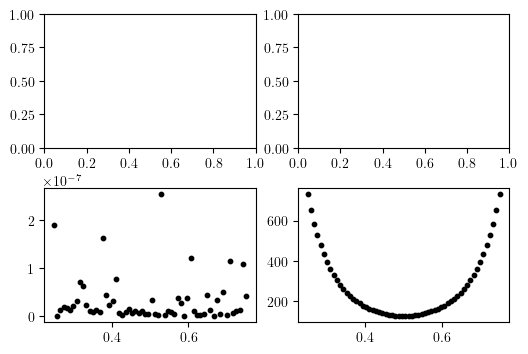

In [ ]:
phis_plot = phis_new
hs_plot = hs_new
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=6,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
gs = gridspec.GridSpec(2,2, figure=fig)
ax = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))

    eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmat@dis
    ax3.scatter(b[i],np.max(beta)/np.max(dmat),color='0',s=10)
    ax4.scatter(b[i],np.max(dmat),color='0',s=10)
plt.subplots_adjust(hspace=0.3)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    # ax3.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)

In [ ]:
def first_order_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length-1,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = -interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = -interaction(latticeA[:,1]-latticeB[:,0],d)
    dmat[ind[:-1:2],ind[:-1:2]]= -inter_1
    dmat[ind[1:-1:2],ind[1:-1:2]]= -inter_2
    dmat[ind[:-1:2],ind[1::2]] = inter_1
    dmat[ind[1:-1:2],ind[2::2]] = inter_2
    return dmat

def grad_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction(dist1,d)
    grad2 = interaction(dist2,d)
    grad_vec = np.zeros(chain_length-1)
    # print(grad1,grad2)
    grad_vec[::2] = grad1
    grad_vec[1::2] = grad2
    return grad_vec
 

def interaction(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2

# chain_length = 6
# dmat = first_order_spph(0.3,0.2,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),d)
# np.round(dmat,2)



In [ ]:

fig, ax = plt.subplots(1,2)
chain_length = 16
Deltap = np.pi
Deltah = 1
N = 3
N_phi = 50
phi_test = np.linspace(-np.pi,np.pi,N_phi)
ds = np.array([np.cos(phi_test),np.sin(phi_test)])
b = np.linspace(0.4,0.6,N)
for i in range(N):
    his = np.linspace(0.2,0.3,N)
    derivatives = np.zeros((N_phi,4))
    # fig, ax = plt.subplots(1,1)
    for j in range(N):
        derivatives = interaction(b[i],his[j],a,chain_length,nom_der1,lambda x, y: dip_derivative_full(x, 0, 0, y),ds)
        print("b: ",b[i],", h: ",his[j])
        fig, ax = plt.subplots(1,1)
        ax.scatter(phi_test,derivatives[:,0]/derivatives[:,2],s=10)
        # ax.scatter(phi_test,derivatives[:,0]/derivatives[:,2],s=10)
        ax.scatter(phi_test,derivatives[:,1]/derivatives[:,3],s=10)
        plt.show()
        

    

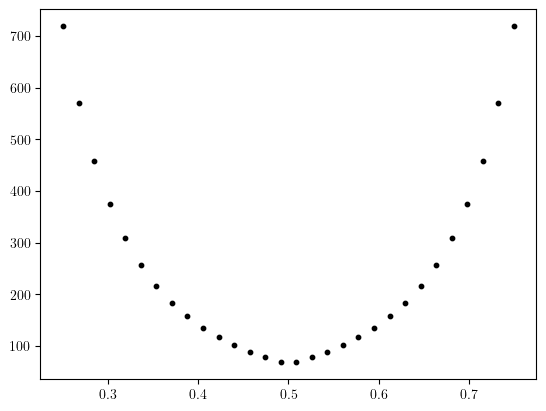

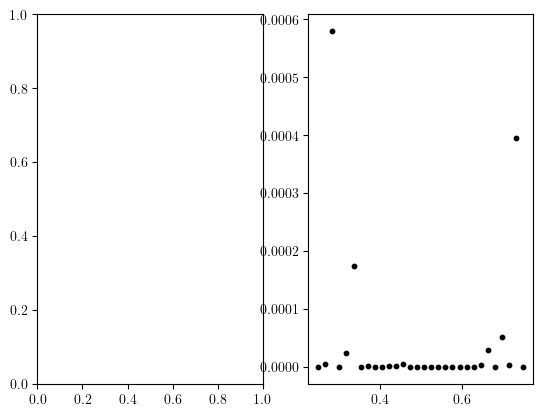

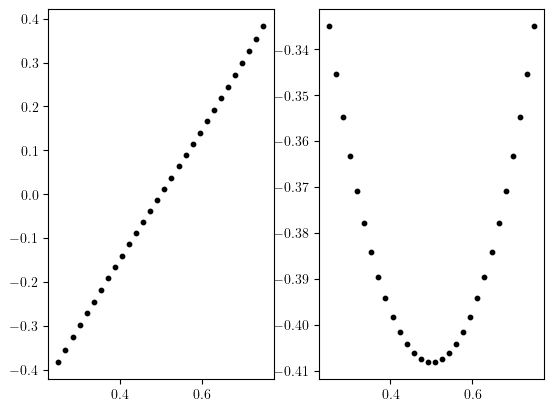

In [57]:
def abs_eigvec(param,b,*paramlast):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = first_order_spph(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),d)
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad_spph(b,h,a,chain_length,nom_der1,d)
    # eigenvecs = np.linalg.solve(dmat,beta)
    eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.max(np.abs(beta))/np.max(np.abs(dmat))
    return np.max(np.abs(eigenvecs))+(np.abs(phid-paramlast[0]) + np.abs(h-paramlast[1]))*1e-6
from scipy.optimize import minimize
N = 30
b = np.linspace(0.25,0.75,N)
phis = np.ones(N)*0*(np.pi)
hs = np.ones(N)*0
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 16
Deltap = np.pi
Deltah = 1
bound_p = (-np.pi/2*3,np.pi/2*3)
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,10)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,10)+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    Deltap = 0.2
    Deltah = 0.1
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            # try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=(b[i],phis[i-1],hs[i-1]),bounds=(bound_p,(-0.5,0.5)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            # except:
            #     pass
    bound_p = (-np.pi/2*3,np.pi/2*3)
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = first_order_spph(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # eig, vec = np.linalg.eig(dmat)
    # ax3[0].scatter(b[i]*np.ones(chain_length-1),eig,color='0',s=30)
    beta = grad_spph(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    vecp = np.linalg.lstsq(dmat,beta)[0]
    dis = dmat@vecp
    ax3[1].scatter(b[i],np.max(dis),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

In [ ]:
Deltah, Deltap = (1,2)
def wrap_func(i,base):
    b = np.linspace(0.25,0.75,N)
    phi_grid = np.linspace(-Deltap,Deltap,10)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,10)+hs[i-1]
    Deltah, Deltap = (0.1,0.2)
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            # try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((0,2*np.pi),(-0.5,0.5)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            # except:
            #     pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    return sorted_crit[0][1], sorted_crit[0][2]
N= 15
# wrapper(0,0)
res = parallel_for([[0,N]],wrap_func,chunk = 3)

In [71]:
pad = 8

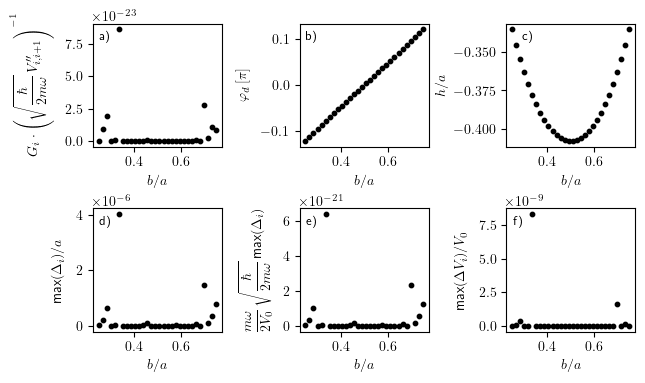

In [81]:
# phis_plot = res[:,0]
# hs_plot = res[:,1]
# N = 15
# b = np.linspace(0.25,0.75,N)
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,3, figure=fig)
# ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,0])
ax5 = fig.add_subplot(gs[1,1])
ax6 = fig.add_subplot(gs[1,2])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = first_order_spph(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    second_order = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad_spph(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    dis = np.linalg.lstsq(dmat,beta)[0]
    # dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    second_der = grad_spph(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    ax1.scatter(b[i],np.max(np.abs(h_new/second_der))*3/1000,color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    Ew = 3*1e-20*10/10**6
    ax4.scatter(b[i],np.max(dis),color='0',s=10)
    ax5.scatter(b[i],np.max(dis)*Ew/V[0]*np.sqrt(c.hbar/2/m/w[0]),color='0',s=10)
    DV1 = beta * (dis[1:]-dis[:-1])
    
    DV2 = 1/2*second_der * (dis[1:]-dis[:-1])**2
    ax6.scatter(b[i],np.max(np.abs(DV1+DV2)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax4.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax1.set_ylabel(r"$$G_i\cdot\left(\sqrt{\frac{\hbar }{2m \omega}}\,{V_{i,i+1}''}\right)^{-1}$$",labelpad=pad)
ax5.set_xlabel(r"$b/a$")
ax5.set_ylabel(r"$$\frac{m\omega}{2V_0}\,\sqrt{\frac{\hbar}{2m\omega}}\,\text{max}(\Delta_i)$$",labelpad=pad)
ax6.set_xlabel(r"$b/a$")
ax6.set_ylabel(r"$\text{max}(\Delta V_i)/V_0$",labelpad=pad)
ax4.text(0.05,0.87,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.05,0.87,"e)",fontsize=9,transform=ax5.transAxes)
ax6.text(0.05,0.87,"f)",fontsize=9,transform=ax6.transAxes)
ax1.text(0.05,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.05,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.12,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.6,hspace=0.5)
plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero_spph.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

In [93]:
dmat = nearest_nb_Hamiltonian(b[0],h,a,8,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
eig, vec = np.linalg.eig(dmat)
np.round(dmat,1), eig

(array([[-1701.3,  1701.3,     0. ,     0. ,     0. ,     0. ,     0. ,
             0. ],
        [ 1701.3, -1678.5,   -22.9,     0. ,     0. ,     0. ,     0. ,
             0. ],
        [    0. ,   -22.9, -1678.5,  1701.3,     0. ,     0. ,     0. ,
             0. ],
        [    0. ,     0. ,  1701.3, -1678.5,   -22.9,     0. ,     0. ,
             0. ],
        [    0. ,     0. ,     0. ,   -22.9, -1678.5,  1701.3,     0. ,
             0. ],
        [    0. ,     0. ,     0. ,     0. ,  1701.3, -1678.5,   -22.9,
             0. ],
        [    0. ,     0. ,     0. ,     0. ,     0. ,   -22.9, -1678.5,
          1701.3],
        [    0. ,     0. ,     0. ,     0. ,     0. ,     0. ,  1701.3,
         -1701.3]]),
 array([ 3.90897870e+01,  2.30072217e+01,  5.36701980e-14,  6.77118539e+00,
        -3.36372729e+03, -3.37996333e+03, -3.40266358e+03, -3.39604590e+03]))

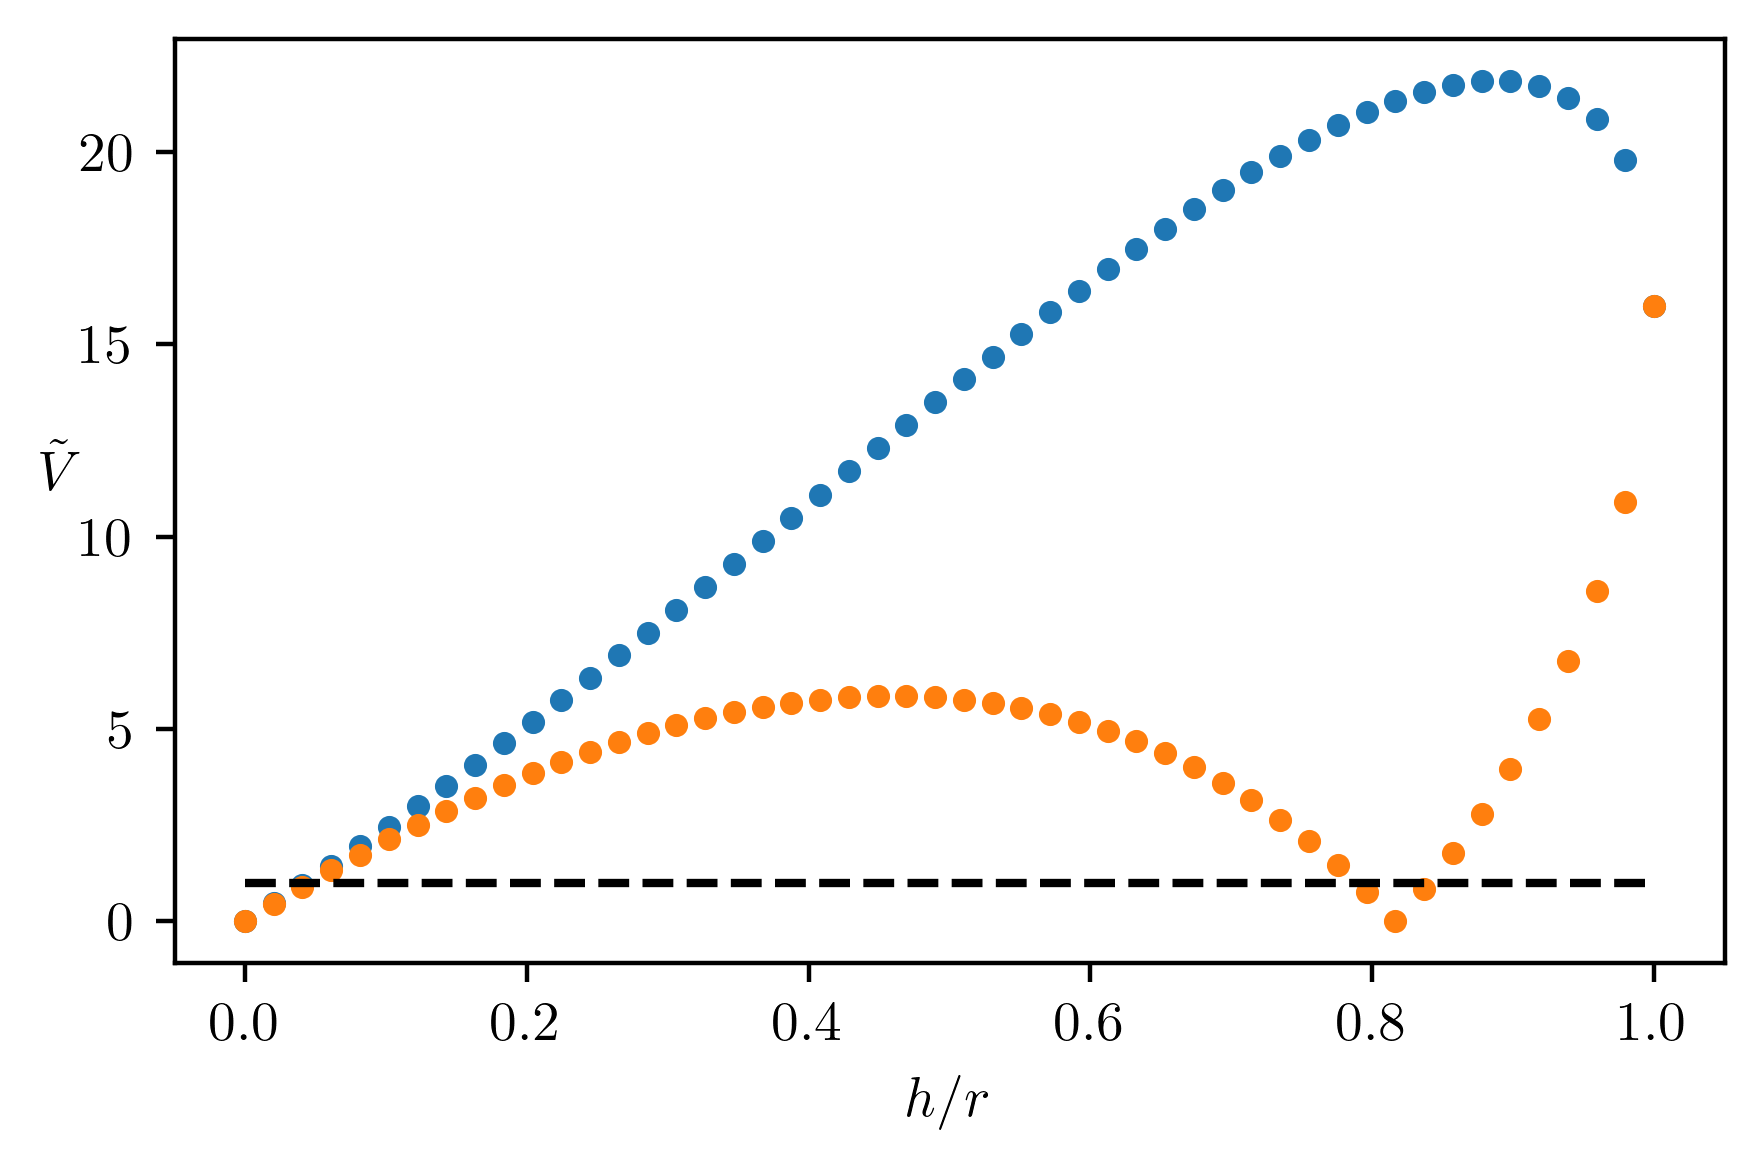

In [12]:
x = np.linspace(0,1)
y1 = -16*(x**2+np.sqrt(2*(1-x**2))*x)
y2 = -16*(x**2-np.sqrt(2*(1-x**2))*x)

setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=5,fig_height=3,xax_share=True,joined=True)

wrapper = [[],[]]
fig, ax = setup.return_fig((1,1))
ax.set_xlabel(r"$h/r$")
ax.set_ylabel(r"$\tilde{V}$",rotation=0)
ax.scatter(x,np.abs(y1),label="-",s=10)
ax.scatter(x,np.abs(y2),label="+",s=10)
ax.hlines(1,x[0],x[-1],linestyle="dashed",color='0')
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"magnitude_derV_ifVzero.pdf")#free_evol_1spto10coupling

plt.show()

In [13]:

"""
Computes ∂f/∂r_x of the function:
 
    f = (1/r^5) * [-3 + 15*(r·d)²/r² - 6*dx² + 60*dx*rx/r²*(r·d) + 15*(rx/r)²*(1 - 7*(r·d)²/r²)]
 
where r = ||(rx, ry)||, r·d = rx*dx + ry*dy.
"""
 
import sympy as sp
 
# ── Symbols ───────────────────────────────────────────────────────────────────
rx, ry, dx, dy = sp.symbols("r_x r_y d_x d_y", real=True)
 
# ── Derived quantities ────────────────────────────────────────────────────────
r2   = rx**2 + ry**2          # r² (avoids sqrt in denominator until the end)
rdot = rx*dx + ry*dy          # r · d
 
# ── Function f ────────────────────────────────────────────────────────────────
bracket = (
    -3
    + 15 * rdot**2 / r2
    - 6 * dx**2
    + 60 * dx * rx / r2 * rdot
    + 15 * rx**2 / r2 * (1 - 7 * rdot**2 / r2)
)
 
f = bracket / r2**sp.Rational(5, 2)   # 1/r^5 = 1/(r²)^(5/2)
 
# ── Derivative ────────────────────────────────────────────────────────────────
df_drx = sp.simplify(sp.diff(f, rx))
df2_drx2 = sp.simplify(sp.diff(df_drx, rx))

# ── Output ────────────────────────────────────────────────────────────────────
print("∂f/∂r_x =")
sp.pprint(df_drx, use_unicode=True)
print()
print("LaTeX:")
print(sp.latex(df_drx))


ModuleNotFoundError: No module named 'sympy'

/tmp/ipykernel_43745/2634336619.py:7: RuntimeWarning: invalid value encountered in sqrt
  dy = np.sqrt(1-dx**2)
/tmp/ipykernel_43745/2634336619.py:33: RuntimeWarning: invalid value encountered in divide
  ax[1].scatter(phi,V/Vder,s=10)


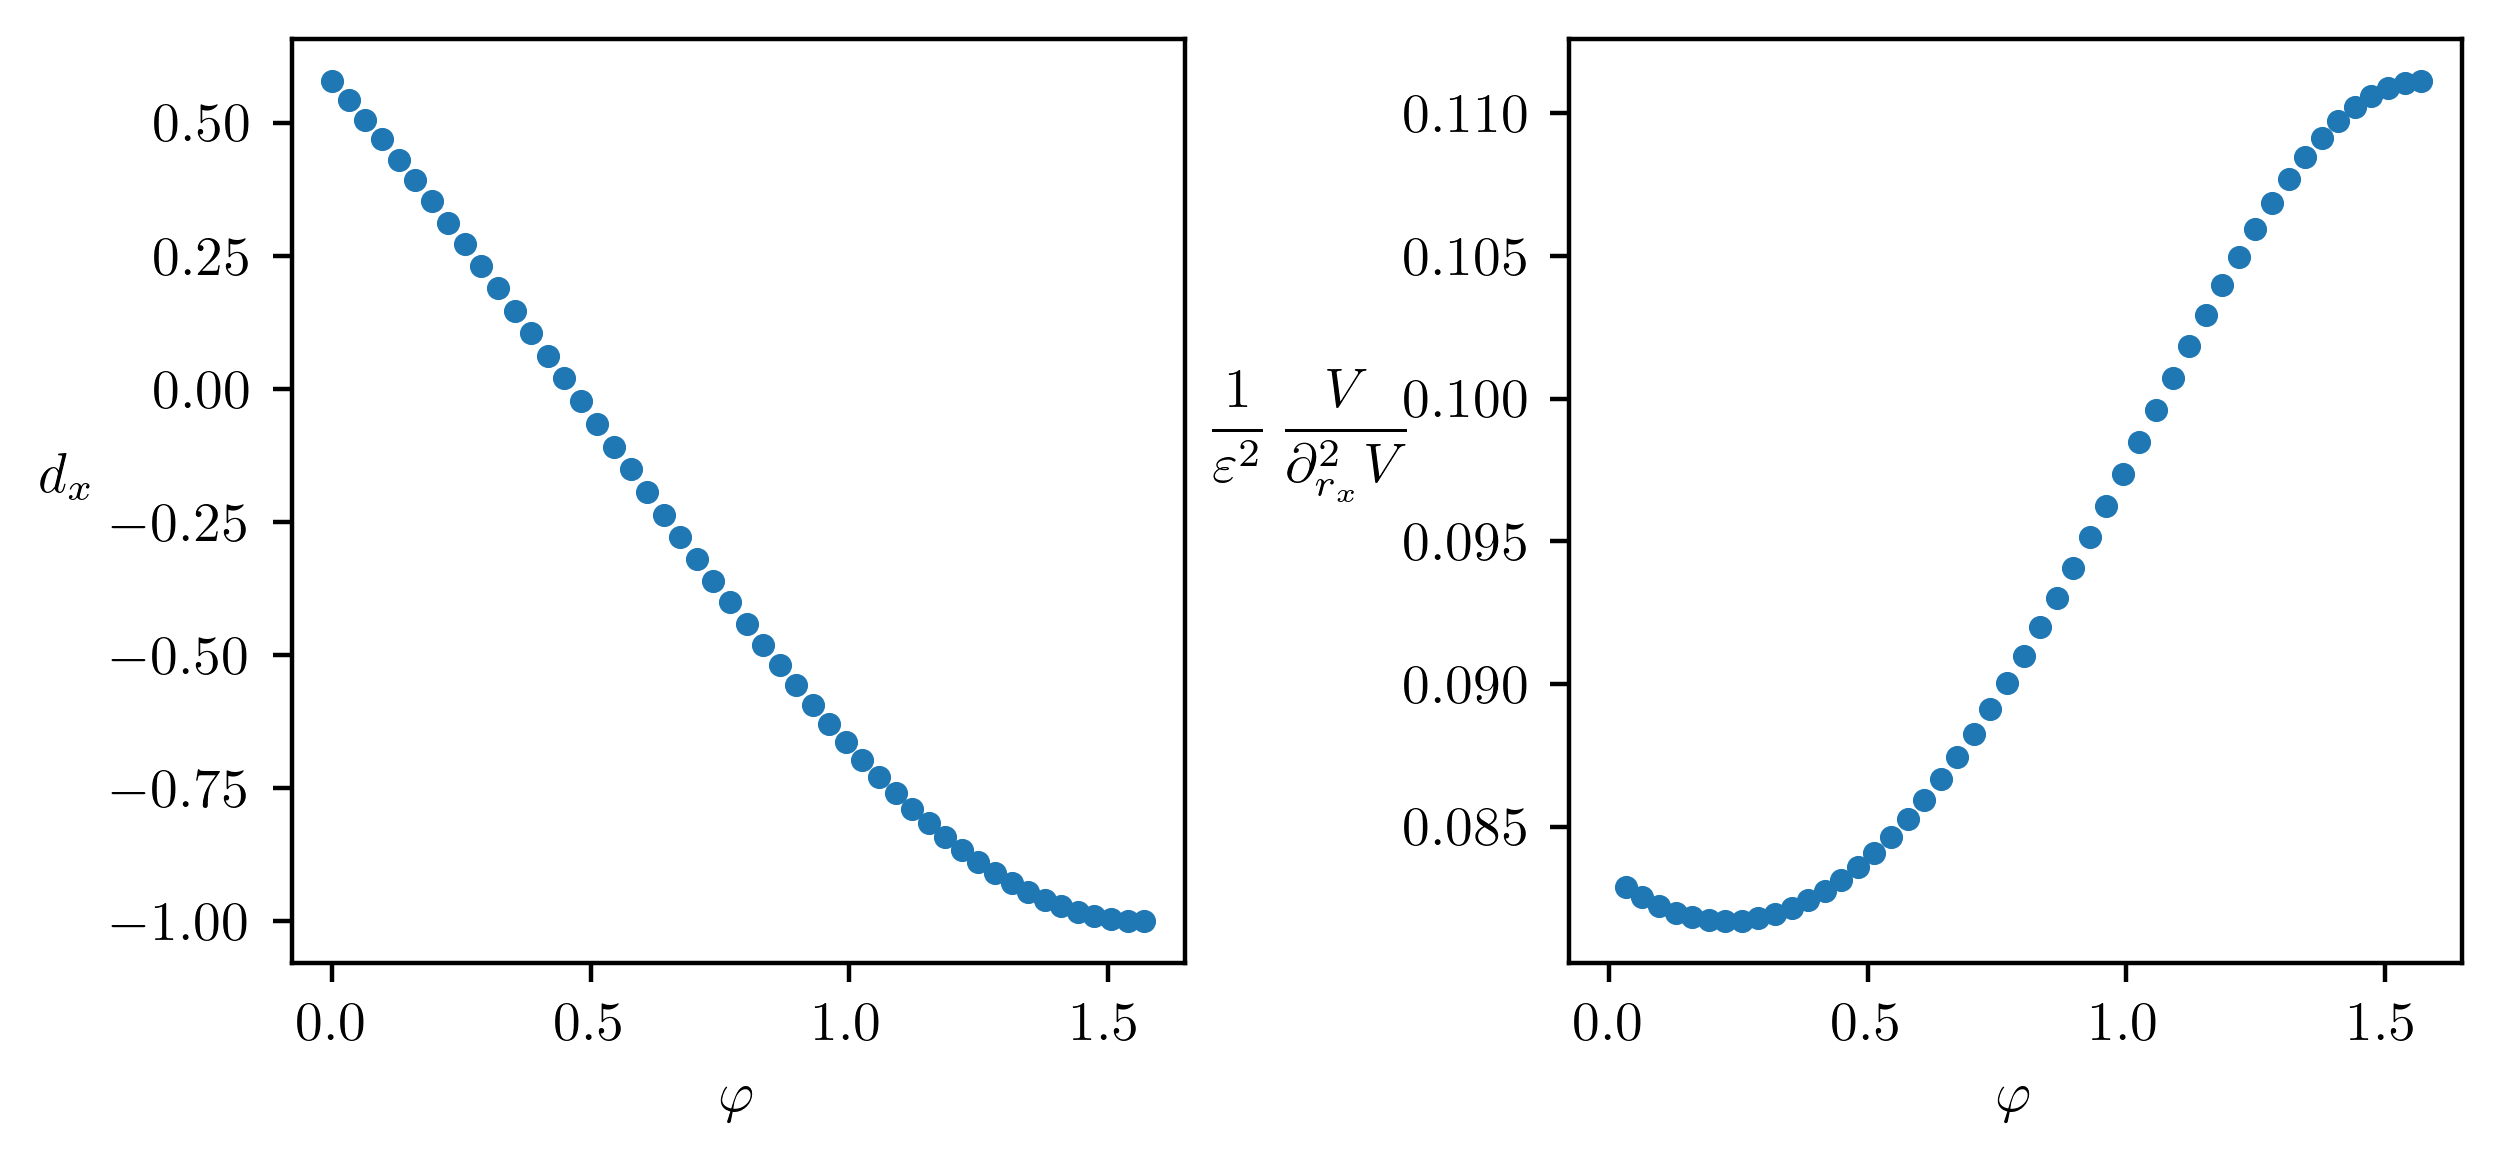

In [ ]:
from scipy.optimize import root_scalar
phi =  np.linspace(0,np.pi/2)

def func(dx,phi):
    rx = np.cos(phi)
    ry = np.sin(phi)
    dy = np.sqrt(1-dx**2)
    f = -3*rx + 15*rx*(rx*dx+ry*dy)**2-6*dx*(rx*dx+ry*dy)
    return f
dip = np.zeros(len(phi))
dip2 = np.zeros(len(phi))
V = np.zeros_like(phi)
Vder = np.zeros_like(phi)
for i in range(len(phi)):
    bracket = (max(-1,0-phi[i]/2*2.8),max(0,0.7-phi[i]/2))
    # bracket = (0,1)
    if func(bracket[0],phi[i])*func(bracket[1],phi[i])<=0:
        root = root_scalar(func,args=phi[i],bracket=bracket)
        # root = root_scalar(func,args=phi[i],x0=0)
        dip[i] = root.root
        Vder[i] = dip_derivative_full(np.array([np.cos(phi[i]),np.sin(phi[i])]),0,0,np.array([dip[i],np.sqrt(1-dip[i]**2)]))
        V[i] = dip_dip(np.array([np.cos(phi[i]),np.sin(phi[i])]),np.array([dip[i],np.sqrt(1-dip[i]**2)]))
    root = root_scalar(func,args=phi[i],x0=0)
    dip2[i] = root.root
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=3,xax_share=True,joined=True)

fig, ax = setup.return_fig((1,2))
ax[0].scatter(phi,dip,s=10)
# ax.scatter(phi,dip2)
# ax.scatter(phi,np.cos(phi))
# plt.show()
# fig, ax = plt.subplots(1,1)
ax[1].scatter(phi,V/Vder,s=10)
# ax.scatter(phi,V)
# ax.scatter(phi,dip2)
ax[0].set_xlabel(r'$\varphi$')
ax[1].set_xlabel(r'$\varphi$')
ax[0].set_ylabel(r"$d_x$",rotation=0,labelpad=8)
ax[1].set_ylabel(r"$$\frac{1}{\varepsilon^2}\,\frac{V}{\partial_{r_x}^2 V}$$",rotation=0,labelpad=17)
plt.subplots_adjust(wspace=0.43)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"magnitude_dersqV_ifderVzero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
#
plt.show()

In [ ]:
2*np.pi*86*c.u, c.hbar, c.u

(8.9727882246588e-25, 1.0545718176461565e-34, 1.66053906892e-27)

In [41]:
import sympy as sp
from sympy import I

# ── Define symbols ────────────────────────────────────────────────────────────
# u, a, b, c, d, w, x, y, z, t = sp.symbols('u a b c d w x y z t')
u = sp.symbols('u')
v, t, s, phia, phib, phix, phiy = sp.symbols(r"v t s phi_a phi_b phi_x phi_y",real=True)
a = sp.sinh(t)*sp.exp(I*phia)
b = sp.cosh(t)*sp.exp(I*phib)
x = sp.sinh(s)*sp.exp(I*phix)
y = sp.cosh(s)*sp.exp(I*phiy)
ust = sp.conjugate(u)
# ── Define a matrix ───────────────────────────────────────────────────────────
M = sp.Matrix([
    [v, u, 0, 0, 0, 0, v, u],
    [ust, v, 0, 0, 0, 0, ust, v],
    [0, 0, v, ust, v, ust, 0, 0],
    [0, 0, u, v, u, v, 0, 0],
    [0, 0, -v, -ust, -v, -ust, 0, 0],
    [0, 0, -u, -v, -u, -v, 0, 0],
    [-v, -u, 0, 0, 0, 0, -v, -u],
    [-ust, -v, 0, 0, 0, 0, -ust, -v]
])

M2 = sp.Matrix([
    [v, u, v, u],
    [ust, v, ust, v],
    [-v, -u, -v, -u],
    [-ust, -v, -ust, -v],
])
# print("Matrix M:")
# sp.pprint(M)

# ── Invert ────────────────────────────────────────────────────────────────────
# ast = sp.conjugate(a)
# bst = sp.conjugate(b)
# cst = sp.conjugate(c)
# dst = sp.conjugate(d)
# wst = sp.conjugate(w)
# xst = sp.conjugate(x)
# yst = sp.conjugate(y)
# zst = sp.conjugate(z)

T = sp.Matrix([
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0]
])
# sp.pprint(T)
S = sp.Matrix([
    [1, 1, 0, 0, 1, 1, 0, 0],
    [1, -1, 0, 0, -1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1, 1],
    [0, 0, 1, -1, 0, 0, -1, 1],
    [1, 1, 0, 0, -1, -1, 0, 0],
    [1, -1, 0, 0, 1, -1, 0, 0],
    [0, 0, 1, 1, 0, 0, -1, -1],
    [0, 0, 1, -1, 0, 0, 1, -1]
])/2
# T_inv = T.inv()#method="ADJ")
S2 = sp.Matrix([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, -1, 0],
    [0, 1, 0, -1],    
])/np.sqrt(2)

T2 = sp.Matrix([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0],
])
# print("\nInverse of T:")
# sp.pprint(S@M@S.T)
# T2@M2@T2.T+M2
S2@M2@S2.T
# sp.pprint(T@M@T)
# # print(T_inv)
# T_inv = sp.simplify(T_inv)
# # display(T_inv)
# M_prime = T_inv @ M @ T
# M_prime = sp.simplify(M_prime)

# # ── Simplify if needed ────────────────────────────────────────────────────────
# M_inv_simplified = sp.simplify(M_inv)
# print("\nSimplified inverse:")
# sp.pprint(M_inv_simplified)

# # ── Verify: M * M_inv should be identity ─────────────────────────────────────
# identity_check = sp.simplify(T @ T_inv)
# print("\nM @ M_inv (should be identity):")
# sp.pprint(identity_check)

Matrix([
[                               0,             0, 0, 0],
[                               0,             0, 0, 0],
[2.0*u + 4.0*v + 2.0*conjugate(u), 2.0*u + 2.0*v, 0, 0],
[        2.0*v + 2.0*conjugate(u),         2.0*v, 0, 0]])

In [39]:
# mpp = M_prime.subs(sp.cosh(t),-sp.sinh(t)*sp.exp(I*(phia+phib)))
# mpp = mpp.subs(sp.cosh(s),-sp.sinh(s)*sp.exp(I*(phix+phiy)))
# mpp = M_prime.subs(t,0)
# # mpp = sp.simplify(mpp)
# display(mpp)
M_prime

Matrix([
[                                  -v*(exp(I*(phi_a + phi_b))*sinh(t) - cosh(t))*(exp(I*(phi_a + phi_b))*cosh(t) + sinh(t))*exp(-I*(phi_a + phi_b)), -u*(exp(I*phi_a)*cosh(s) + exp(I*(phi_a + phi_x + phi_y))*sinh(s))*(exp(I*(phi_a + phi_b))*cosh(t) + sinh(t))*exp(-I*(2*phi_a + phi_y)),                                                                                                                                       0,                                                                                                                                                  0,                                                                                                                                       0,                                                                                                                                                  0,                                                                          -v*(exp(2*I*(phi_a + phi_b))*cosh(t)**2 - cosh(t)**2 + 1)*exp(